# Mechanistic Analysis for Pre-Training (and Post-Training) Science

Mechanistic Interpretability was developed to give humans the ability to supervise AI systems in a rigorous quantitative fashion, with the goal of improving our ability to control, verify, and steer the outputs of increasingly powerful machine learning models. 

While the most obvious application of mech interp lies in AI Safety & Existential Risk (which we'll discuss next week) an under-researched and increasingly important application of mech interp techniques is studying learning dynamics with the goal of improving pre and post training science, as well as neural architectures themselves. 

This week we'll study a few recent and highly impactful papers which in this field which, grounding the 


## Case Study 1: Why Gradient Norms Increase Rapidly at the End of Training (https://arxiv.org/pdf/2506.02285)

A well-observed phenomenon in machine learning is that gradient norms increase rapidly near the end of training when both weight-decay and learning rate schedulers are used

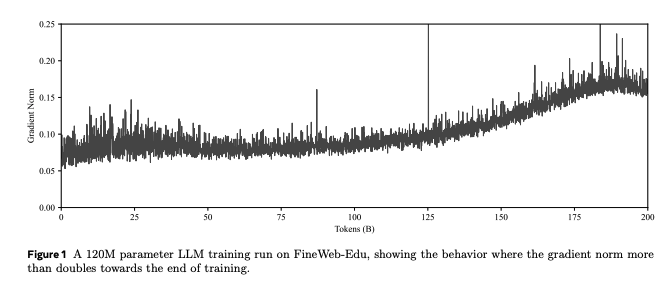

The authors argue that this is due to an unintended interaction between the learning rate $\gamma$ and the weight decay parameter $\lambda$ that emerges when training via AdamW (one of the most common optimizers, though becoming less common since Muon's widespread adoption)

The weight update for vanilla stochastic gradient descent (SGD) is 

$$x_{t+1} = x_t - \gamma g_t - \gamma \lambda x_t$$

Where $g_t$ gives the gradient and $\gamma \lambda x_t$ is the weight decay parameter. Adam (Adaptive Moment Estimation) improves the speed and stability of convergence by approximating second order gradient information via two momentum buffers

$$x_{t+1} = x_t - \gamma \frac{\hat{m}_t + \gamma \lambda x_t}{\sqrt{\hat{v}_t} + \epsilon} $$

Where the momentum buffers $\hat{m}_t$ and $\hat{v}_t$ are given by

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$

and $\hat{m}_t$ and $\hat{v}_t$ are debiased terms (meaning we correct for the fact that $m_t$ and $v_t$ are initialized at zero, which biases them toward zero in early steps):

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

One issue with Adam is that the weight decay term $\gamma \lambda x_t$ is present in the numerator of the gradient, which means that we decay weights in proportion to the denominator $\sqrt{\hat{v}_t} + \epsilon$, so weights that have a larger 2nd moment buffer get shrunk less because we're dividing the numerator by a larger denominator. It's been demonstrated empirically that it's usually best in pretraining to uniformly decay model weights. AdamW (Adaptive Moment Estmation with Decoupled Weight Decay) solves this by decoupling the weight decay term from the gradient update

$$x_{t+1} = x_t - \gamma \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} - \gamma \lambda x_t$$

But this introduces an unintended interaction between the learning rate $\gamma$ and the weight decay parameter $\lambda$. If we assume the layers are normalized beforehand and no momentum buffer is used (so $\hat{m}_t = g_t$), then we get this weight update rule:

$$x_{t+1} = x_t - \gamma_t A_t^{-1} g_t - \gamma_t \lambda x_t$$

Where $A_t^{-1} = \text{diag}(\frac{1}{\sqrt{\hat{v}_t} + \epsilon})$

Now let's look at tte gradient norms at *steady state dynamics* ($x_t \approx x_{t+1}$ and $A_t \approx a_{t+1}$)

$$\|x_{t+1}\|_{A_t}^2 = \|x_t - \gamma A_t^{-1} g_t - \gamma \lambda x_t\|_{A_t}^2$$

$$\|x_{t+1}\|_{A_t}^2 = (1 - \gamma \lambda)^2 \|x_t\|_{A_t}^2 - 2(1 - \gamma \lambda) \gamma \langle A_t^{-1} g_t, A_t x_t \rangle + \gamma^2 \|A_t^{-1} g_t\|_{A_t}^2$$

If we assume $\langle A_t^{-1} g_t, A_t x_t \rangle = 0$ (the gradients and weights are orthogonal because the layer has been normalized), we get this:

$$\|x_{t+1}\|_{A_t}^2 = (1 - \gamma \lambda)^2 \|x_t\|_{A_t}^2 + \gamma^2 \|g_t\|_{A_t^{-1}}^2.$$

$$\|x_t\|_{A_t}^2 \left[1 - (1 - \gamma\lambda)^2\right] = \gamma^2 \|g_t\|_{A_t^{-1}}^2$$

$$\frac{\|g_t\|_{A_t^{-1}}^2}{\|x_t\|_{A_t}^2} \propto \sqrt{\frac{2\lambda}{\gamma_t}}$$


Why does this matter? this ratio is going to *continually increase* throughout training. Thnk about it. The numerator is constant (we don't change the lr decay rate) and the denominator on the right side the equation is decreasing because we're decaying the learning rate as a function of train step. So the left side of the equation blows up. What does this do for gradient norms? Because learning rate is decreasing and weight decay is constant, you can think of us pushing the norm of the model weights $\|x_t\|^2$ towards zero. This drives a corresponding increase in gradient norm as a mathematical result of this equation*. That in turn can lead to instability and inefficiency late in model training. Typically this isn't felt much because the learning rate has decreased enough that parameter updates are small, but it is still felt. 

*(also note that this is *not* merely a correlational relationship. This derivation comes directly from the steady state update rule, meaning this is not a statistical relationship; the model update literally is forced to satisfy this relationship because of how the algebra works)

We can observe this empirically by running a small-scale pretraining run on a NanoGPT using AdamW to drive gradient descent: 

In [6]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

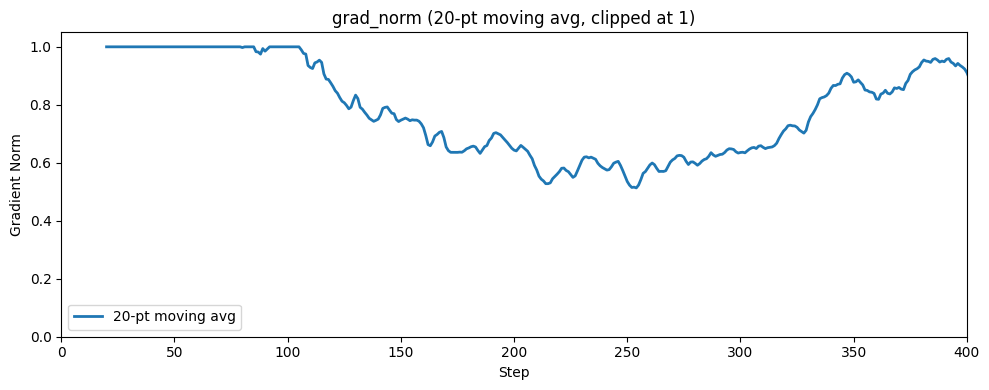

In [8]:
# Pull data from the W&B run
api = wandb.Api()
run = api.run("jaredjunkin-johns-hopkins-university/owt/ta1uydas")
history = run.history(keys=["grad_norm"], pandas=True)

# Compute 20-point moving average and clip to [0, 1]
history["grad_norm_smooth"] = history["grad_norm"].rolling(window=20).mean().clip(upper=1)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history["_step"], history["grad_norm_smooth"], linewidth=2, label="20-pt moving avg")
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 400)
ax.set_xlabel("Step")
ax.set_ylabel("Gradient Norm")
ax.set_title("grad_norm (20-pt moving avg, clipped at 1)")
ax.legend()
plt.tight_layout()
plt.show()

We can fix this problem by scaling our weight decay term $\lambda$ according to the learning rate at timestep $t$ $\gamma_t$:

$$\lambda_t = \frac{\gamma_t}{\gamma_\text{max}}$$
Where $\gamma_\text{max}$ gives the max learning rate. If we plug that into the relationship we derived above we get

$$\frac{\|g_t\|_{A_t^{-1}}^2}{\|x_t\|_{A_t}^2} \propto \sqrt{\frac{2\lambda_t}{\gamma_t}} = \sqrt{\frac{2\frac{\gamma_t}{\gamma_\text{max}}}{\gamma_t}} = \sqrt{\frac{2}{\lambda_\text{max}}}$$

And this term is a constant! So that means scaling our weight decay term in proportion to the decreasing learning rate means our gradient norms shouldn't blow up at the end of training. 

## Case Study 2: State-Tracking in LLMs and Gated Linear Recurrent RNNs

Imagine you have 5 cups in front of you, with a coin underneath the center one. The cups are rotated and you need to determine which cup the coin is under at the end. This is the state-tracking problem, and it's become an important benchmark of LLM capabilities in recent years.

One mathematical formulation of the state tracking problem is permutation composition: performing a series of permutations on an initial sequence to reorder it



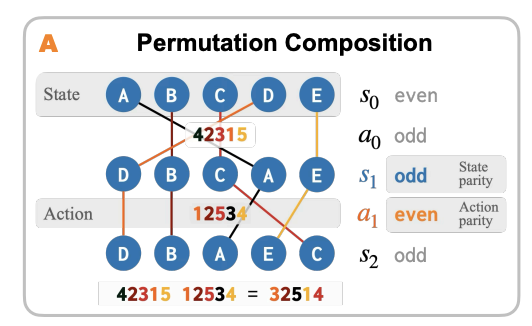


We can express a permutation composition in code like this:

In [2]:
# import modules
from fla.models import GatedDeltaNetConfig, GatedDeltaProductConfig
import fla.models
from transformers import AutoModelForCausalLM
import torch
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
### Now let's git clone the state tracking problem and confirm I can import that
from utils.data_loaders import ChunkedDataset
from utils.data_collators import DataCollatorForLanguageModelingWithNextTokenSupervision
from utils.model_utils import setup_tokenizer
from permutation_task import PermutationTask
from torch.utils.data import DataLoader


Current Triton version 3.1.0 is below the recommended 3.2.0 version. Errors may occur and these issues will not be fixed. Please consider upgrading Triton.


In [7]:
# Look at a single raw example
### load in the dataset
NUM_ITEMS = 5
MAX_LEN = 120
BATCH_SIZE = 256
DATA_DIR = "data/test"

# Create the permutation task (needed for token definitions)
task = PermutationTask(num_items=NUM_ITEMS)
state_tokens = {state.permutation: state.to_string() for state in task.states}
action_tokens = {action.permutation: action.to_string() for action in task.actions}
print("defined permutation task")
dataset = ChunkedDataset(DATA_DIR, max_len=MAX_LEN)
example = dataset[0]
print(f"\nKeys: {list(example.keys())}")
# print(f"\nRaw story text (first 200 chars):\n{example['story'][:200]}")
print(f"\nActions to Apply: {example['story'].split()[:20]} ...")
# print(f"Actions to Apply: {len(example['story'].split())}")
print(F"States (Ground Truth Model Must Track): {example['state_seq'][:20]}")

defined permutation task

Keys: ['story', 'state_seq']

Actions to Apply: ['14352', '25431', '43215', '31542', '15243', '32415', '42153', '43125', '43125', '14532', '53124', '52314', '31245', '45123', '13425', '25431', '32145', '21435', '51243', '45231'] ...
States (Ground Truth Model Must Track): [[1, 2, 3, 4, 5], [1, 4, 3, 5, 2], [4, 2, 5, 3, 1], [3, 5, 2, 4, 1], [2, 3, 1, 4, 5], [2, 5, 3, 4, 1], [3, 5, 4, 2, 1], [2, 5, 3, 1, 4], [1, 3, 2, 5, 4], [5, 2, 1, 3, 4], [5, 3, 4, 1, 2], [2, 4, 5, 3, 1], [1, 4, 5, 2, 3], [5, 1, 4, 2, 3], [2, 3, 5, 1, 4], [2, 5, 1, 3, 4], [5, 4, 3, 1, 2], [3, 4, 5, 1, 2], [4, 3, 1, 5, 2], [2, 4, 3, 5, 1]]


Notice how we can turn this into a next token prediction problem. At each index $t$, the model can be trained to predict `states[t+1]` via the standard categorical crossentropy loss

$$\mathcal{L} = -\sum_{c=1}^{C} y_c \log(\hat{y}_c)$$


So we know that, in theory, we can pretrain a LLM to solve this. But what algorithm would it implement in practice? 

Below are four candidate algorithms

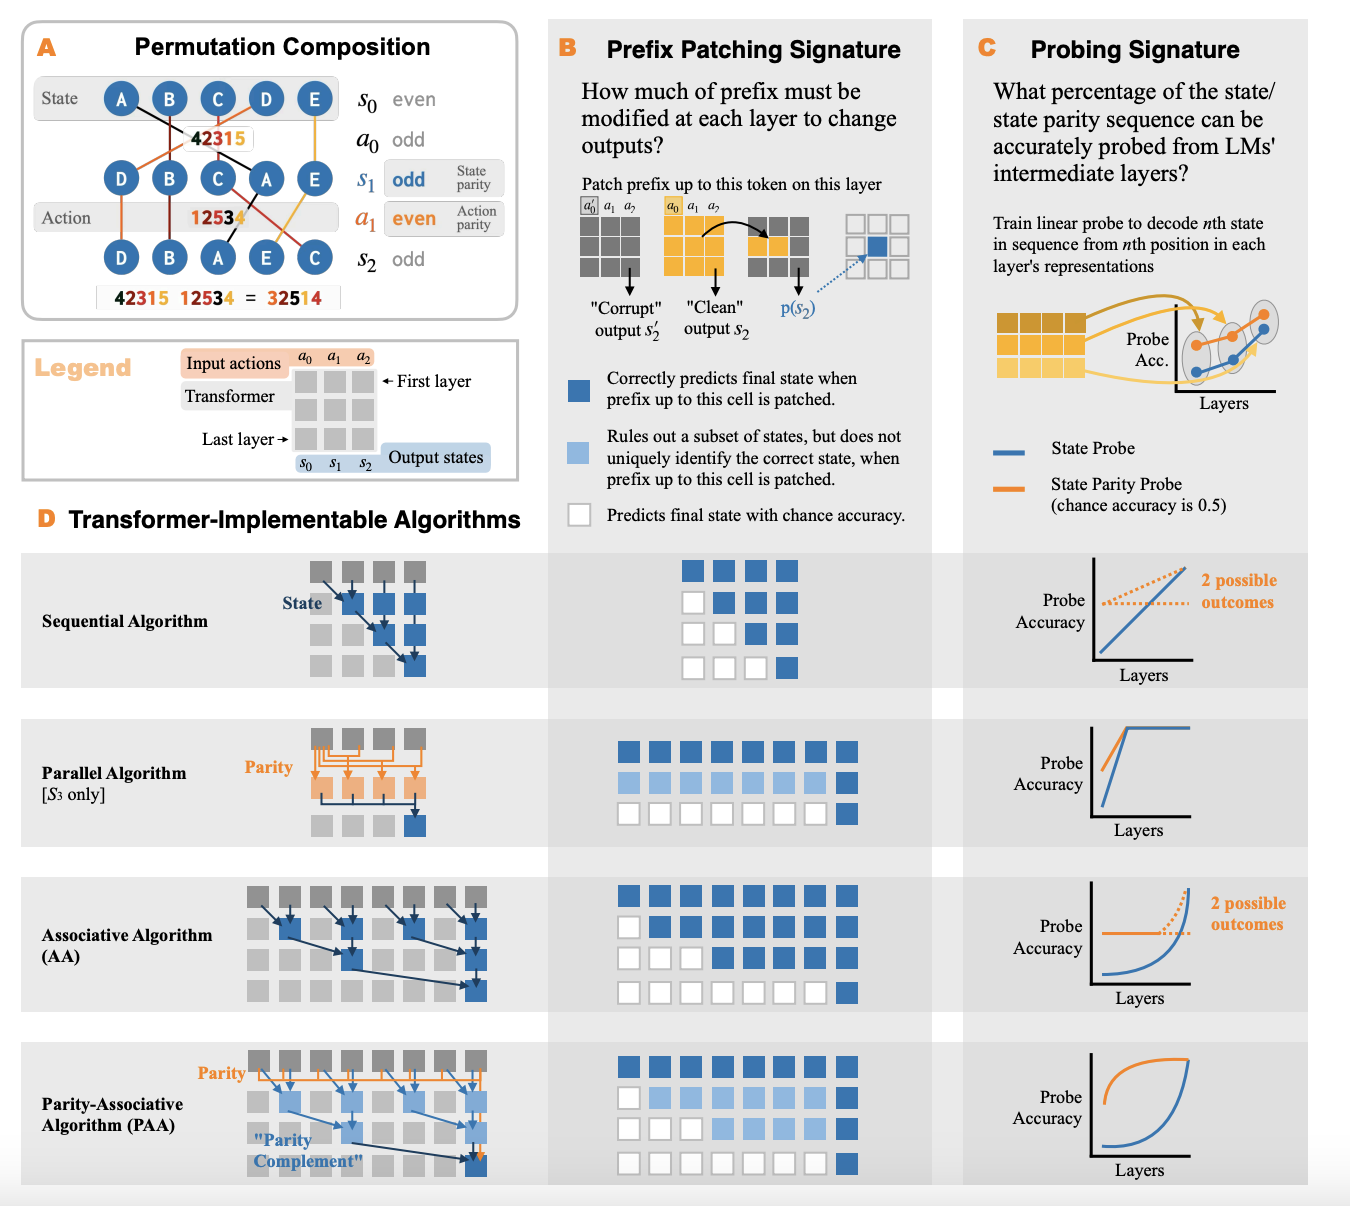

The first is the **sequential algorithm**, which composes permutations one at a time from left to right, maintaining a running state at each layer. At layer $l$, the hidden state at position $t$ stores the cumulative product $s_t = a_0 \cdots a_t$ only once $l = t$. This has the serious limitation that for sequences of length $n$ it would require $n$ transformer layers to implement, making it highly unlikely to be the algorithm learned in practice.

The second is the **parallel algorithm**, which computes the final state in a constant number of layers regardless of sequence length. Note that this is not possible for our problem ($S_5$, which means composing permutations of 5 elements). The parallel algorithm cannot solve this task because $S_5$ is $\text{NC}^1$-complete, meaning it provably cannot be solved by fixed-depth transformers for arbitrary sequence lengths.

The remaining two algorithms use a tree-based approach and exhibit a logarithmic relationship between sequence length and the number of layers required. The **associative algorithm** (AA) exploits the associativity of permutation composition ($a_0 a_1 a_2 a_3 = (a_0 a_1)(a_2 a_3)$) to hierarchically compose adjacent subsequences at each layer, doubling the length of the composed subsequence with each additional layer. This gives the model the ability to handle sequences of length up to $2^L$ with $L$ layers. The **parity-associative algorithm** (PAA) first computes the parity of the final permutation — whether it decomposes into an even or odd number of transpositions — in a constant number of early layers, pruning the space of possible outputs by half. It then uses an associative scan over the remaining "parity complement" to determine the exact final state. While PAA can converge faster initially (by exploiting the easy parity heuristic), models that learn AA tend to generalise better to longer sequences.

It's worth noting that the authors predict what probing and activation patching signatures they'd expect to see if the model were implementing this algorithm. 

Why this signature for the probes? Because at layer $l$ our model will have composed the first $2^l$ permutations in the sequence. The authors are predicting those ones can be linearly read out and the rest can't (I'm not fully convinced by this prediction but that's what they claim). I think the patching predictions are much better and more revealing because those deal only with what information is present and causally informs later computations, not what is linearly accessible. 

### Results:

Authors train lanuage models on the S5 and S3 tasks and then perform probing and patching. Their probing results indicate a log-linear relationship between position and the layer at which the state becomes linearly decodable, indicating that the models are learning an associative (tree-based) composition algorithm rather than a sequential or parallel one.

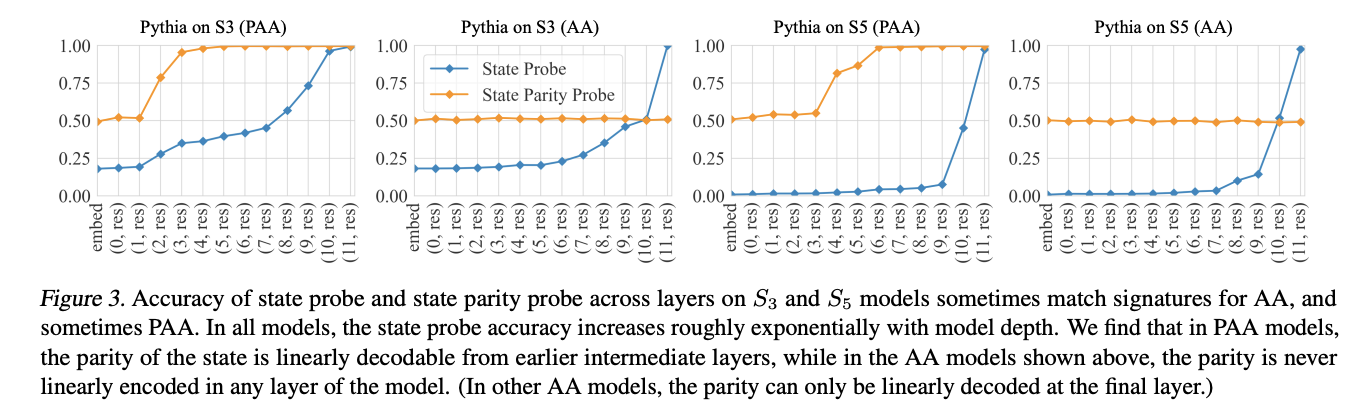

Their patching results also exhibit a log-linear relationship between layer depth and the length of prefix that must be restored to recover the correct prediction. Specifically, at deeper layers, exponentially longer prefixes can be ignored without affecting the model's output, indicating that the model has already compressed that prefix information into fewer token positions towards the final token, consistent with the hierarchical merging of the associative algorithm.

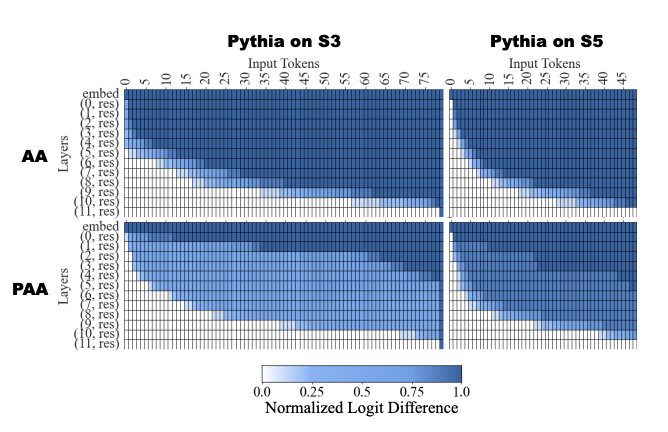

### Linear Attention
As you all know, standard attention has $O(n^2)$ computational complexity in sequence length because every token attends to every previous token. Specifically the formula for attention

$$\text{Output} = \underbrace{\text{softmax}(QK^T / \sqrt{d_v})}_{(n \times d_v) \cdot (d_v \times n)} \cdot \underbrace{V}_{n \times d_v} = \mathbb{R}^{n \times d_v}$$

where $Q \in \mathbb{R}^{n \times d_k}$, $K \in \mathbb{R}^{n \times d_k}$, and $V \in \mathbb{R}^{n \times d_v}$ are the query, key, and value matrices respectively. Includes a multiplication of an $n \times n$ matrix, which is why the computational complexity is $O(n^2)$. But if we remove the softmax and *linearize* attention, we get

$$\text{Output} = Q \cdot K^T \cdot V$$

And we can then perform the computations in this order because matrix multiplications are associative

$$\text{Output} = Q \cdot \underbrace{(K^T V)}_{d_k \times d_v} = \mathbb{R}^{n \times d_v}$$

Which means we no longer have to multiply an $(n \times n)$ matrix and the complexity of the operation becomes linear rather than quadratic. This is the idea behind Mamba and a whole family of *linear attention* mechanisms

### Transformer Architectures as State Space Models

Notice the final equation above can be written recursively. For a single token position $t$ with causal masking, the output is:

$$o_t = q_t^T \left(\sum_{i=1}^{t} k_i v_i^T\right)$$

The sum accumulates one new term at each step, so defining $S_t = \sum_{i=1}^{t} k_i v_i^T$ gives us:

$$S_t = S_{t-1} + k_t v_t^T, \quad o_t = S_t q_t$$

Note that $k_i \in \mathbb{R}^{d_k}$ and $v_i \in \mathbb{R}^{d_v}$ are vectors, so $k_i v_i^T$ is an outer product producing a full $d_k \times d_v$ matrix in which every key dimension interacts with every value dimension:

$$k_i v_i^T = \begin{pmatrix} k_1 v_1 & k_1 v_2 & \cdots & k_1 v_{d_v} \\ k_2 v_1 & k_2 v_2 & \cdots & k_2 v_{d_v} \\ \vdots & \vdots & \ddots & \vdots \\ k_{d_k} v_1 & k_{d_k} v_2 & \cdots & k_{d_k} v_{d_v} \end{pmatrix}$$

The state $S_t$ accumulates $t$ of these matrices, one from each past token, into a single fixed-size $d_k \times d_v$ matrix:

$$S_t = \underbrace{k_1 v_1^T}_{\text{token 1}} + \underbrace{k_2 v_2^T}_{\text{token 2}} + \cdots + \underbrace{k_t v_t^T}_{\text{token } t}$$

When we compute $o_t = S_t q_t$, the output is influenced by all past tokens via their contributions to $S_t$ — this is where cross-token mixing occurs, despite the recurrence only updating a single matrix at each step.

This means that, in addition to asymptotically lower computational complexity, linear attention mechanisms also introduce the concept of state — a strength of early NLP architectures like RNNs and LSTMs that vanilla transformers lack. This should mean that they are capable of modeling arbitrarily long $S_5$ sequences because they are recurrent. But what mechanism would they use for state tracking? 

### Mechanism of State Tracking in Linear Recurrent Models

Two linear recurrent architectures that are in theory uniquely well-suited for the $S_5$ problem are Gated DeltaNet and DeltaProduct.

Recall the vanilla linear attention recurrence:

$$S_t = S_{t-1} + k_t v_t^T, \quad o_t = S_t q_t$$

### DeltaNet

DeltaNet replaces the simple additive update with the *delta rule*, which first erases the old value associated with the current key before writing a new one:

$$S_t = S_{t-1}(\mathbf{I} - \beta_t k_t k_t^T) + \beta_t v_t k_t^T$$

The matrix $(\mathbf{I} - \beta_t k_t k_t^T)$ is a *generalized Householder transformation*. When $\beta_t = 2$, a householder transformation acts as a reflection about the hyperplane $k_t$: 

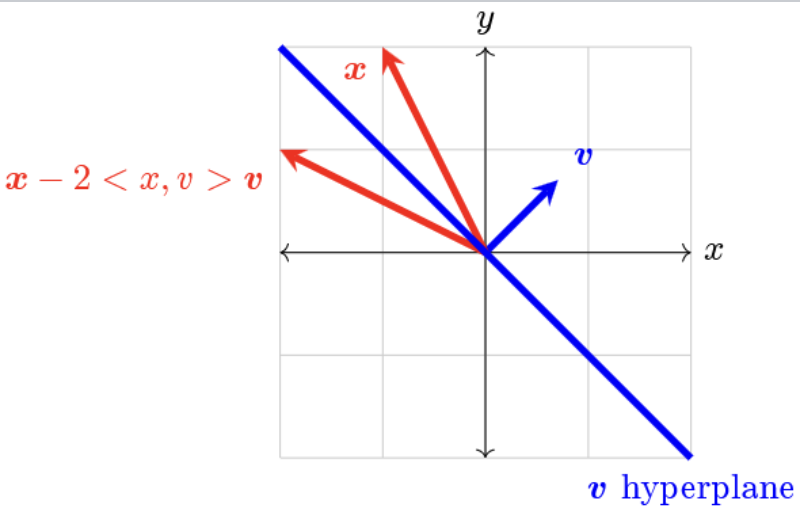

When $\beta=1$ it erases the component of $S_{t-1}$ along $k_t$ before writing a new value — effectively allowing the model to selectively suppress basis vectors in its state and write new ones, forming what is effectively an adaptive associative memory cache. When $\beta=1$ it forms an identity transformation. When $0 < \beta < 1$ it can be thought of as a contraction along the direction $k_t$. 

So you can think of this as once again you can think of this householder transformation as forming an learnable associative memory, which we further augment by adding a data-dependent decay gate $\alpha_t \in (0,1)$ for adaptive memory management:

$$S_t = S_{t-1}\left(\alpha_t(\mathbf{I} - \beta_t k_t k_t^T)\right) + \beta_t v_t k_t^T$$

However, a single Householder transformation per step is a rank-1 update to the state-transition matrix, which limits the kinds of linear transformations the model can perform on its state at each step (for example, it **cannot** do rotations. 

### DeltaProduct

Recall the state update equation for DeltaNet:

$$S_t = (\mathbf{I} - \beta_t k_t k_t^T) S_{t-1} + \beta_t k_t v_t^T$$

If we took a second gradient descent step on this same layer, using a fresh key $k_{t,2}$, value $v_{t,2}$, and writing strength $\beta_{t,2}$, we'd get:

$$S_{t,1} = (\mathbf{I} - \beta_{t,1} k_{t,1} k_{t,1}^T) S_{t-1} + \beta_{t,1} k_{t,1} v_{t,1}^T$$

$$S_{t,2} = (\mathbf{I} - \beta_{t,2} k_{t,2} k_{t,2}^T) S_{t,1} + \beta_{t,2} k_{t,2} v_{t,2}^T$$

$$S_t = (\mathbf{I} - \beta_{t,2} k_{t,2} k_{t,2}^T)(\mathbf{I} - \beta_{t,1} k_{t,1} k_{t,1}^T) S_{t-1} + (\mathbf{I} - \beta_{t,2} k_{t,2} k_{t,2}^T)\beta_{t,1} k_{t,1} v_{t,1}^T + \beta_{t,2} k_{t,2} v_{t,2}^T$$
If we did this $n_h$ times we'd have:

$$S_t = \prod_{j=1}^{n_h} \left(\mathbf{I} - \beta_{t,j} k_{t,j} k_{t,j}^T\right) S_{t-1} + \sum_{j=1}^{n_h} \left(\prod_{l=j+1}^{n_h} \left(\mathbf{I} - \beta_{t,l} k_{t,l} k_{t,l}^T\right) \beta_{t,j} k_{t,j} v_{t,j}^T\right)$$

This is the idea behind DeltaProduct. We unroll an $n_h$-step recurrence within each layer, allowing the model to form more expressive state-transition matrices as the product of multiple Householder transformations.


#### Proof that DeltaProduct Impelements Arbitrary Rotation in 2D Plane

When $n_h = 2$ and we set $\beta_{t,j} = 2$, each Householder matrix becomes a reflection about a hyperplane. By the Cartan-Dieudonné theorem, the composition of two reflections about different hyperplanes is an arbitrary rotation in the 2D subspace they span: 

Consider two unit vectors $k_1, k_2$ with angle $\theta$ between them. With $\beta = 2$:

$$H_1 = \mathbf{I} - 2k_1 k_1^T, \quad H_2 = \mathbf{I} - 2k_2 k_2^T$$

Both act as the identity orthogonal to $\text{span}(k_1, k_2)$, so restrict to the 2D subspace. The product is:

$$H_2 H_1 = (\mathbf{I} - 2k_2 k_2^T)(\mathbf{I} - 2k_1 k_1^T) = \mathbf{I} - 2k_1 k_1^T - 2k_2 k_2^T + 4(k_2^T k_1) k_2 k_1^T$$

Restricted to this subspace, this has 
$$\det(H_2 H_1) = (-1)(-1) = 1$$ 

because the determinant of a reflection is -1, and 

$$\text{tr}(H_2 H_1) = 2 - 2 - 2 + 4\cos^2\theta = 2\cos(2\theta)$$ 

because 

- $\text{tr}(\mathbf{I}) = 2$
- $\text{tr}(k_1 k_1^T) = \|k_1\|^2 = 1$, so $-2 \cdot 1 = -2$
- $\text{tr}(k_2 k_2^T) = \|k_2\|^2 = 1$, so $-2 \cdot 1 = -2$
- $\text{tr}(k_2 k_1^T) = k_1^T k_2 = \cos\theta$, so $4\cos\theta \cdot \cos\theta = 4\cos^2\theta$

So that means these are exactly the determinant and trace of the 2D rotation matrix $R(2\theta)$ because the 2D rotation matrix by angle $\phi$ is:

$$R(\phi) = \begin{pmatrix} \cos\phi & -\sin\phi \\ \sin\phi & \cos\phi \end{pmatrix}$$

So $\det(R(\phi)) = \cos^2\phi + \sin^2\phi = 1$ and $\text{tr}(R(\phi)) = 2\cos\phi$. Setting $\phi = 2\theta$ gives $\det = 1$ and $\text{tr} = 2\cos(2\theta)$, matching what we computed for $H_2 H_1$.

Since any angle can be achieved by choosing the appropriate $\theta$, two Householder reflections compose to form an arbitrary rotation.

A permutation of elements happens to correspond to a rotation (or reflection) in the appropriate basis. So by setting $n_h = 2$, we give the network the ability to track state in the $S_5$ problem in a more direct manner than key-value associative memory: we allow it to directly perform rotations on its state-space matrix as it proceeds through the sequence of permutations.

### Train DeltaNet and DeltaProduct on S5

(See Train Scripts in train.py)

Open source implementations of DeltaNet and DeltaProduct available on the flash linear attention GitHub repo (https://github.com/fla-org/flash-linear-attention). We trained DeltaNet and Deltaproduct implementations for 20 epochs on a corpus of 1,000,000 100-length sequences of S5 Permutations. We used a single A100 GPU with 40GB of RAM and used mixed precision training. These were the hyperparameters we used.


| Parameter | Value |
|---|---|
| vocab_size | len(tokenizer) |
| hidden_size | 256 |
| num_hidden_layers | 4 |
| num_heads | 8 |
| lr | 1e-3 |
| lr_decay | linear|
| max_grad_norm| 1.0|


Saved to figures/eval_lines.png


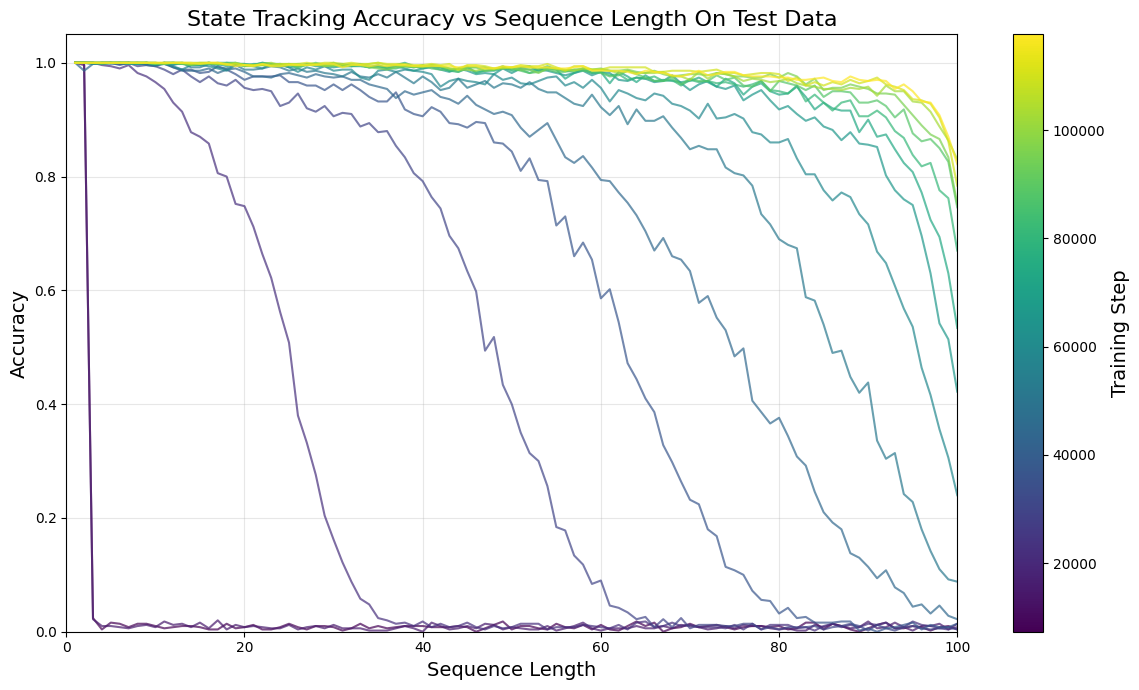

In [4]:
# Plot superimposed line charts colored by checkpoint step
fig, ax = plt.subplots(figsize=(12, 7))

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=min(steps), vmax=max(steps))

for i, step in enumerate(steps):
    color = cmap(norm(step))
    accs = [results[step].get(sl, 0.0) for sl in seqlens]
    ax.plot(seqlens, accs, color=color, alpha=0.7, linewidth=1.5, label=f"step {step}")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Training Step", fontsize=14)

ax.set_xlabel("Sequence Length", fontsize=14)
ax.set_ylabel("Accuracy", fontsize=14)
ax.set_title("State Tracking Accuracy vs Sequence Length On Test Data", fontsize=16)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, max(seqlens))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/eval_lines.png", dpi=300, bbox_inches="tight")
print("Saved to figures/eval_lines.png")
plt.show()

# DeltaProduct (above): Contour Map (X-Axis: Sequence Length, Y-Axis: Accuracy, lines colored by checkpoint)
# DeltaNet (below): Contour Map (X-Axis: Sequence Length, Y-Axis: Accuracy, lines colored by checkpoint)
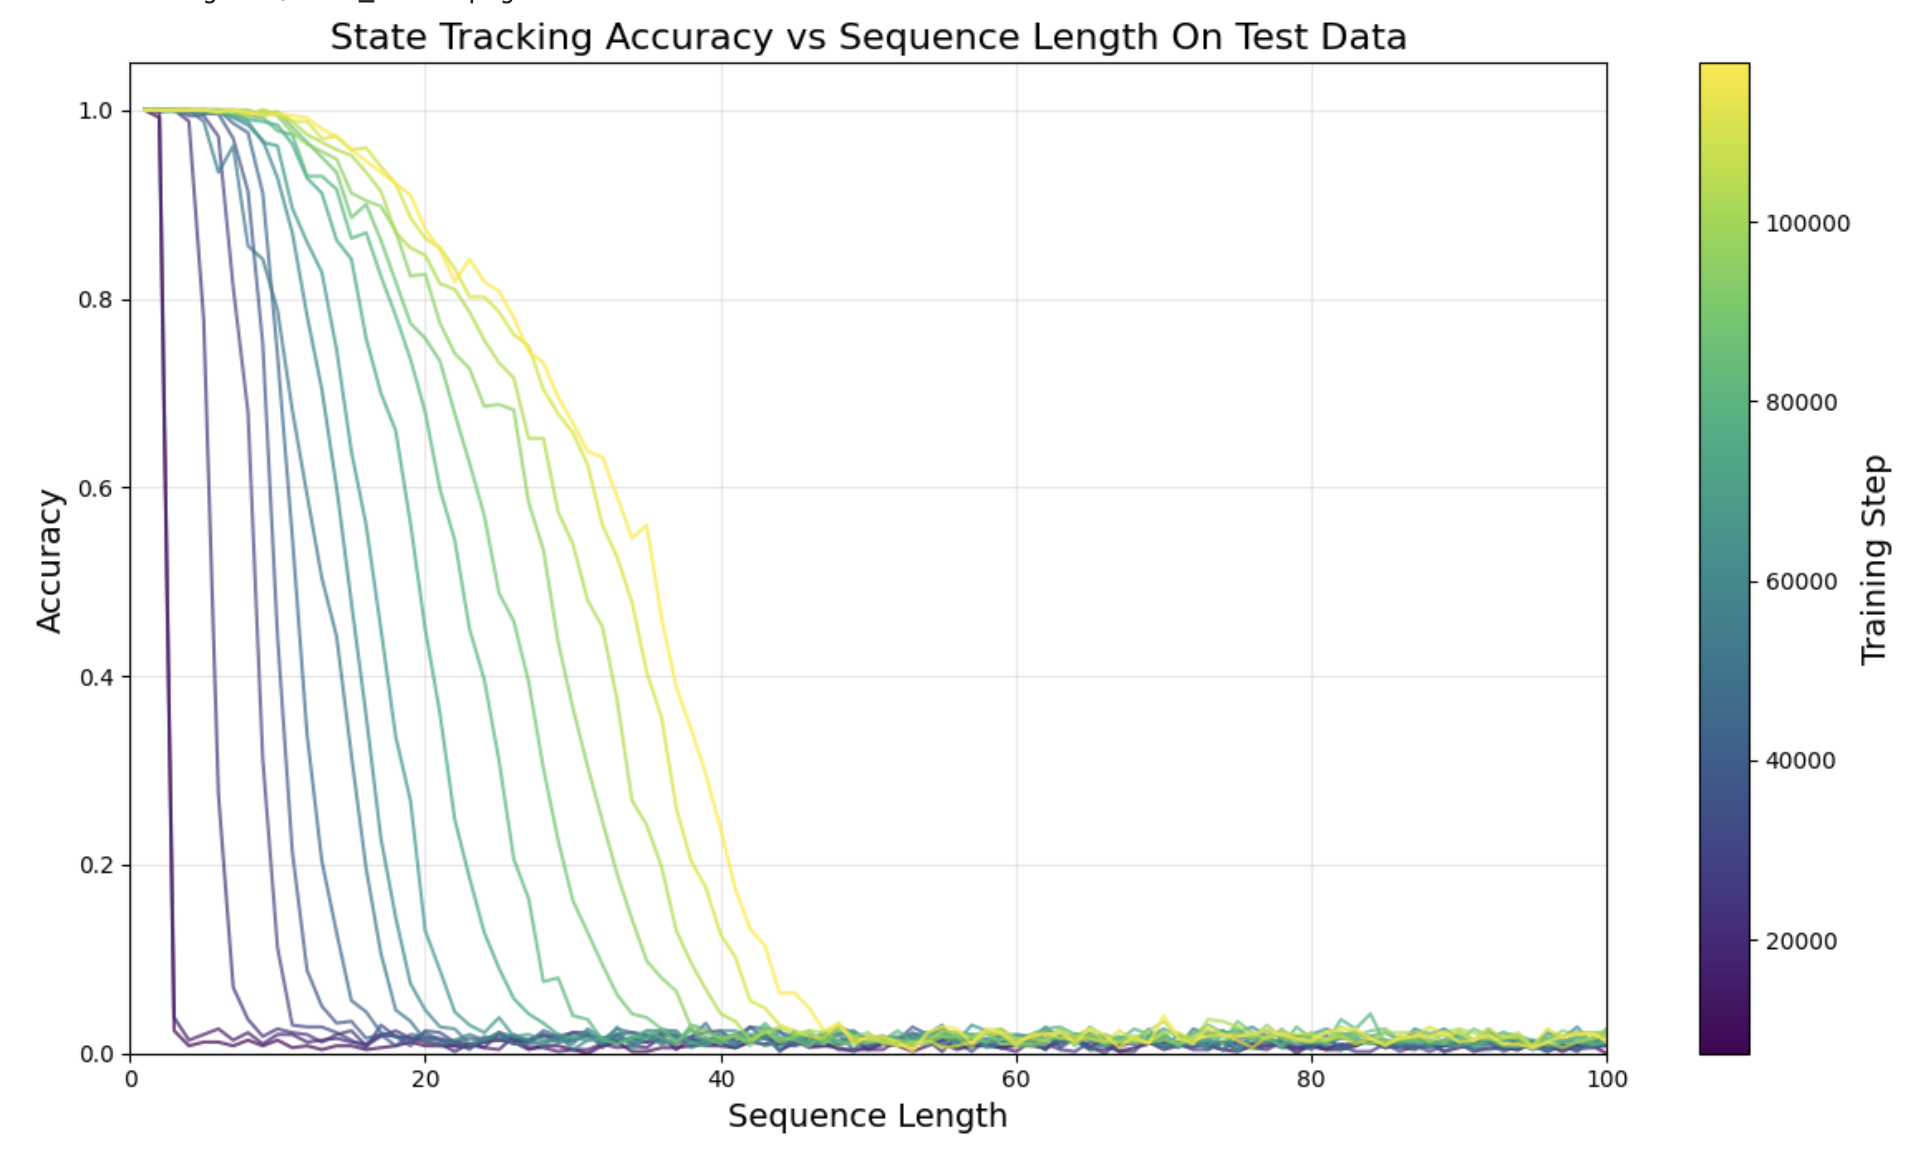

Note that deltanet performed substantially worse and appears significanlty undertrained. Perhaps this is because DeltaNet has to learn a less efficient way of tracking state due to its more limited expressiveness? 


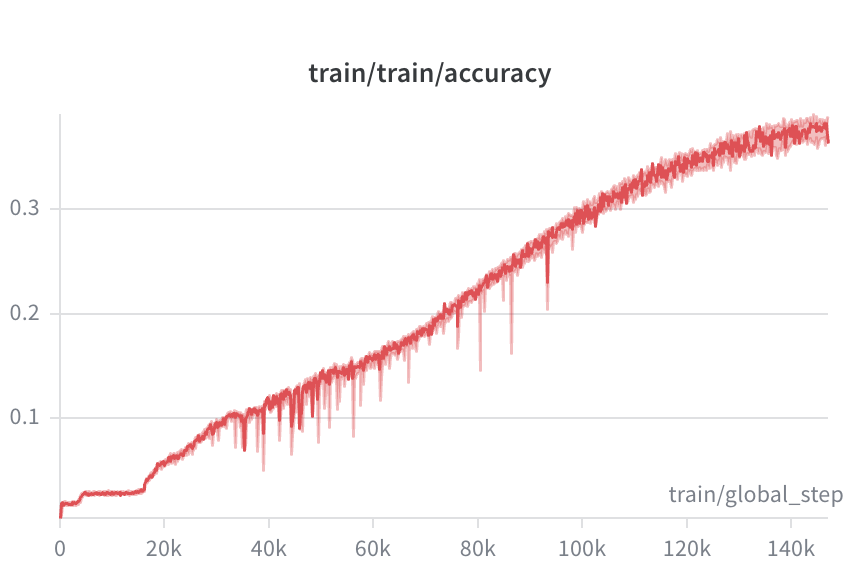
 



### Mechanistic Hypotheses: 

- DeltaNet will handle state tracking by iteratively performing rank-1 updates to its state space via associative memory reads and writes
- DeltaProduct will leverage Householder Products to perform rotations on its internal state. These rotations will be *context independent* and will efficiently represent the permutation at time $t$

### Experimental Design (DeltaProduct)
For each sequence in our test set, we step through the model in recurrent mode one token at a time, recording the recurrent state $S_t$ at every position. Separately, we run a parallel forward pass with hooks on `k_conv1d` and `b_proj` to extract the k vectors and beta scalars at each position. From these we reconstruct the Householder matrix $H_t = (I - \beta_1 k_1 k_1^\top)(I - \beta_2 k_2 k_2^\top)$. We then compute the relative error $\|H_t @ S_{t-1} - S_t\| / \|S_t\|$ at every position across every layer. If this error is small, it means the Householder product dominates the state update and the contribution from the additive write is negligible. We repeat this across 50 sequences and 100 token positions per sequence.

## Step 1: Load in Dataset and Model Ckpt

In [ ]:
# Setup of problem & loading in dataset

task = PermutationTask(num_items=NUM_ITEMS)
state_tokens = {state.permutation: state.to_string() for state in task.states}
action_tokens = {action.permutation: action.to_string() for action in task.actions}
tokenizer = create_permutation_tokenizer(state_tokens, action_tokens) # both models use the same tokenizer.

# load dataset
dataset = ChunkedDataset(DATA_DIR, max_len=MAX_LEN)
print("hello world")
print(len(dataset))
print(f"len tokenizer is {len(tokenizer)}")

hello world
10917
len tokenizer is 241


/data/snatha11/tilde-takehome/.venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
# config = GatedDeltaProductConfig(vocab_size=len(tokenizer))
config = GatedDeltaProductConfig(
    vocab_size=len(tokenizer),
    hidden_size=256,
    num_hidden_layers=4,
    num_heads=8,
    num_householder=2, # 2 householder products because that composes into an arbitrary rotation
)
model = AutoModelForCausalLM.from_config(config)
state_dict = load_file(os.path.join(DELTAPROD_MODEL_DIR, DELTAPROD_CHECKPOINT_DIR, "model.safetensors"))
model.load_state_dict(state_dict)
print(f"loaded checkpoint {DELTAPROD_CHECKPOINT_DIR}")
model = model.to(device)
model.eval()
print(model)

/data/snatha11/tilde-takehome/.venv/lib/python3.11/site-packages/fla/modules/convolution.py:593: UserWarning: The `backend` parameter is set to `cuda`, but `causal_conv1d_fn` is not available. Switching to the Triton implementation instead. Consider installing `causal_conv1d` to enable the CUDA backend.
  warnings.warn(


loaded checkpoint checkpoint-117680
GatedDeltaProductForCausalLM(
  (model): GatedDeltaProductModel(
    (embeddings): Embedding(241, 256)
    (layers): ModuleList(
      (0-3): 4 x GatedDeltaProductBlock(
        (attn_norm): RMSNorm(256, eps=1e-06)
        (attn): GatedDeltaProduct(
          (q_proj): Linear(in_features=256, out_features=2048, bias=False)
          (k_proj): Linear(in_features=256, out_features=4096, bias=False)
          (v_proj): Linear(in_features=256, out_features=8192, bias=False)
          (b_proj): Linear(in_features=256, out_features=16, bias=False)
          (q_conv1d): ShortConvolution(2048, 2048, kernel_size=(4,), stride=(1,), padding=(3,), groups=2048, bias=False, activation=silu, backend=triton)
          (k_conv1d): ShortConvolution(4096, 4096, kernel_size=(4,), stride=(1,), padding=(3,), groups=4096, bias=False, activation=silu, backend=triton)
          (v_conv1d): ShortConvolution(8192, 8192, kernel_size=(4,), stride=(1,), padding=(3,), groups=8192,

## Step 2: Experiment!

In [16]:
# ============================================================
# Householder prediction experiment
# ============================================================

def compute_householder_product(cache, layer, pos, model):
    """
    Build the Householder product matrix from cached k and beta projections.
    For DeltaProduct with num_householder=2, this composes two reflections.
    """
    attn = model.model.layers[layer].attn
    num_h = attn.num_householder
    nh = attn.num_heads
    dk = attn.head_k_dim

    # Extract k vectors from the cache and split into num_householder groups per head
    k_raw = cache[f"model.layers.{layer}.attn.k_conv1d"][0, pos]
    k = einops.rearrange(k_raw, '(n nh dk) -> n nh dk', n=num_h, nh=nh, dk=dk)
    # Normalize so k @ k^T is a projection matrix
    k = F.normalize(k, p=2, dim=-1)

    # Extract beta scalars and split into num_householder groups per head
    beta_raw = torch.sigmoid(cache[f"model.layers.{layer}.attn.b_proj"][0, pos])
    beta = einops.rearrange(beta_raw, '(n nh) -> n nh', n=num_h, nh=nh)

    # Compose reflections: H = (I - beta_2 k_2 k_2^T)(I - beta_1 k_1 k_1^T)
    I = torch.eye(dk, device=k.device).unsqueeze(0).expand(nh, -1, -1)
    H = I.clone()
    for j in range(num_h):
        reflection = I - beta[j, :, None, None] * einops.einsum(k[j], k[j], 'h i, h j -> h i j')
        H = reflection @ H
    return H


def compute_deltanet_householder(cache, layer, pos, model):
    """
    Build the single-reflection multiplicative matrix for DeltaNet.
    DeltaNet only has one Householder factor per layer, so this is just I - beta * k * k^T.
    """
    nh = 8  # adjust if your DeltaNet has a different head count
    dk = cache[f"model.layers.{layer}.attn.k_conv1d"][0, pos].shape[0] // nh

    # Extract and reshape k: one vector per head
    k_raw = cache[f"model.layers.{layer}.attn.k_conv1d"][0, pos]
    k = einops.rearrange(k_raw, '(nh dk) -> nh dk', nh=nh, dk=dk)
    k = F.normalize(k, p=2, dim=-1)

    # Extract beta: one scalar per head
    beta_raw = torch.sigmoid(cache[f"model.layers.{layer}.attn.b_proj"][0, pos])
    beta = einops.rearrange(beta_raw, '(nh) -> nh', nh=nh)

    # Build single reflection: H = I - beta * k * k^T
    I = torch.eye(dk, device=k.device).unsqueeze(0).expand(nh, -1, -1)
    H = I - beta[:, None, None] * einops.einsum(k, k, 'h i, h j -> h i j')
    return H


def get_hook_names(num_layers):
    """Return module paths we need to hook for extracting k and beta."""
    return [f"model.layers.{l}.attn.k_conv1d" for l in range(num_layers)] + \
           [f"model.layers.{l}.attn.b_proj" for l in range(num_layers)]


def test_householder_prediction(model, dataset, tokenizer, householder_fn,
                                 num_layers=4, num_examples=50, max_pos=60,
                                 compose_layers=None):
    """
    Test how well the Householder product explains recurrent state updates.
    For each sequence position, compares H @ S_{t-1} to the actual S_t.
    
    Args:
        householder_fn: function(cache, layer, pos, model) -> H matrix per head
        compose_layers: if provided, compose H across these layers and test the
                        composed product against the full multi-layer state change.
                        Use this to test DeltaNet cross-layer composition hypothesis.
    """
    hook_names = get_hook_names(num_layers)
    results = {layer: [] for layer in range(num_layers)}

    for idx in range(min(num_examples, len(dataset))):
        example = dataset[idx]
        tokens = example['story'].split()[:max_pos]
        states = example['state_seq'][1:max_pos + 1]
        input_ids = tokenizer(" ".join(tokens), return_tensors='pt').input_ids.cuda()

        # Run parallel forward pass to get k and beta at every position
        cache = run_with_cache(model, input_ids, hook_names)

        for layer in range(num_layers):
            # Step through recurrently to get the actual S at each position
            past_kv = None
            with torch.no_grad():
                for pos in range(len(tokens)):
                    # Save S before this step
                    S_before = past_kv[layer]['recurrent_state'].clone() if past_kv is not None else None

                    # Run one recurrent step to get S after
                    out = model(input_ids=input_ids[:, pos:pos + 1], past_key_values=past_kv, use_cache=True)
                    past_kv = out.past_key_values
                    S_after = past_kv[layer]['recurrent_state'].clone()

                    # Skip first position since there's no S_before
                    if S_before is None:
                        continue

                    # Build the Householder matrix from the cached projections
                    H = householder_fn(cache, layer, pos, model)

                    # Predict S_after using only the Householder product
                    predicted = einops.einsum(H, S_before[0], 'nh i j, nh j dv -> nh i dv')

                    # Measure relative error between prediction and actual
                    error = (predicted - S_after[0]).norm() / S_after[0].norm()

                    results[layer].append({
                        'example': idx,
                        'pos': pos,
                        'action_token': tokens[pos],
                        'error': error.item(),
                    })

        if idx % 10 == 0:
            print(f"Processed {idx}/{num_examples}")

    return results


def print_results_summary(results):
    """Print per-layer mean, median, std of Householder prediction error."""
    for layer in sorted(results.keys()):
        errors = [r['error'] for r in results[layer]]
        print(f"Layer {layer}: mean error = {np.mean(errors):.4f}, "
              f"median = {np.median(errors):.4f}, std = {np.std(errors):.4f}")


def plot_error_vs_position(results):
    """Plot mean Householder prediction error vs sequence position per layer."""
    plt.figure(figsize=(10, 5))
    for layer in sorted(results.keys()):
        positions = sorted(set(r['pos'] for r in results[layer]))
        pos_means = []
        for p in positions:
            errs = [r['error'] for r in results[layer] if r['pos'] == p]
            pos_means.append(np.mean(errs))
        plt.plot(positions, pos_means, label=f'Layer {layer}')
    plt.xlabel('Position')
    plt.ylabel('Mean Householder-only error')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title('Householder prediction error vs sequence position')
    plt.show()


Processed 0/50
Processed 10/50
Processed 20/50
Processed 30/50
Processed 40/50
Layer 0: mean error = 0.3802, median = 0.3510, std = 0.1129
Layer 1: mean error = 0.3185, median = 0.2819, std = 0.1010
Layer 2: mean error = 0.4054, median = 0.3896, std = 0.1258
Layer 3: mean error = 0.1637, median = 0.0438, std = 0.2668


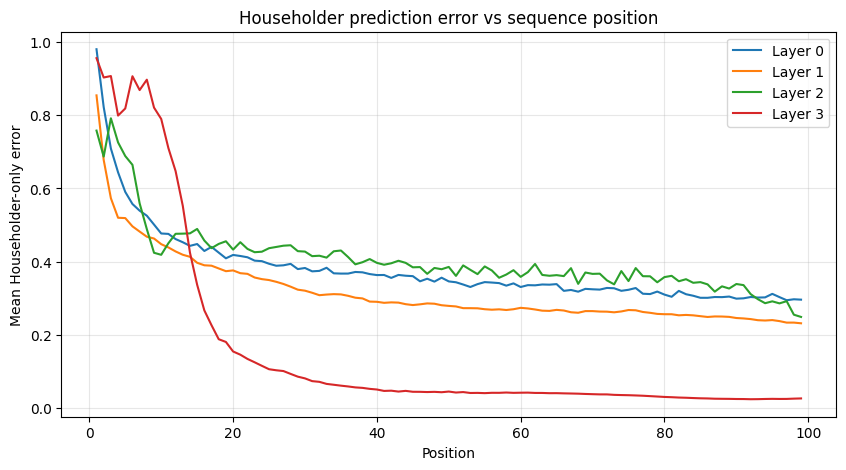

In [17]:
results = test_householder_prediction(model, dataset, tokenizer,
                                       householder_fn=compute_householder_product,
                                       num_examples=50, max_pos=100)
print_results_summary(results)
plot_error_vs_position(results)

## Analysis of Plot

This plot shows the mean Householder prediction error $\frac{\|(H_t \cdot S_{t-1} - S_t)\|}{\|S_t\|}$ at each sequence position, broken out by layer.

Why do the means appear so high when they're written out above? It's because they average across sequence length. It appears that for the first 20 tokens or so our DeltaProduct does not track state using householder products but is instead busy populating its recurrent state (additive writes are more important to forming state here). Then for longer sequences, once the recurrent state is populated, it performs updates on that state as rotations with the householder product. 

Also it's noteworthy that the final layer of the model has the representation which depends most cleanly on householder products. This suggests that earlier layers (0-2) are responsible for processing the input token and computing the projections (k vectors and betas) that determine which rotation to apply, while layer 3 is where the actual state tracking happens via the Householder product. The earlier layers prepare the rotation by determining which inputs to apply, and layer 3 executes it on the recurrent state.

Another piece of evidence for this division of labor is that there is little differencein Householder prediction error for correctly and incorrectly predicted tokens (see scatter plot below). When the model predicts incorrectly, the householder prediction error is not meaningfully higher than the error on correctly predicted tokens, suggesting that the failure mode is not in the rotation mechanism itself but in the upstream computation of k vectores and betas that parameterize it. The Householder's role is to execute the permutation. The role of determining which permutation to execute happens elsewhere and is where these next token prediction errors appear to originate. 


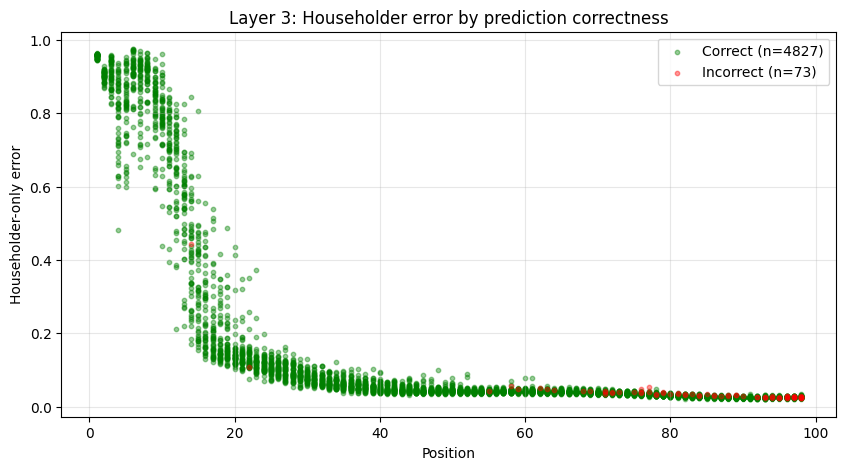

In [ ]:
DELTAPRODUCT_HOOK_NAMES = [
    f"model.layers.{l}.attn.k_conv1d" for l in range(4)
] + [
    f"model.layers.{l}.attn.b_proj" for l in range(4)
] + [
    f"model.layers.{l}.attn.a_proj" for l in range(4)
]

def get_final_prediction_correctness(model, dataset, tokenizer, num_examples=50, max_pos=100):
    """For each (example, position), check if the model's next-token prediction is correct."""
    correctness = {}
    
    for idx in range(min(num_examples, len(dataset))):
        example = dataset[idx]
        tokens = example['story'].split()[:max_pos]
        states = example['state_seq'][1:max_pos + 1]
        input_ids = tokenizer(" ".join(tokens), return_tensors='pt').input_ids.cuda()
        
        with torch.no_grad(), torch.autocast('cuda', dtype=torch.bfloat16):
            logits = model(input_ids).logits[0]  # [seq_len, vocab]
        
        for pos in range(len(tokens) - 1):
            predicted_token = tokenizer.decode([logits[pos].argmax().item()])
            # The target is the next state in the sequence
            target_state = ''.join(str(x) for x in states[pos])
            correct = (predicted_token.strip() == target_state.strip())
            correctness[(idx, pos)] = correct
    
    return correctness


def plot_error_vs_position_by_correctness(results, correctness, layer=3):
    """Scatter plot of Householder error vs position, colored by prediction correctness."""
    correct_pos, correct_err = [], []
    incorrect_pos, incorrect_err = [], []
    
    for r in results[layer]:
        key = (r['example'], r['pos'])
        if key not in correctness:
            continue
        if correctness[key]:
            correct_pos.append(r['pos'])
            correct_err.append(r['error'])
        else:
            incorrect_pos.append(r['pos'])
            incorrect_err.append(r['error'])
    
    plt.figure(figsize=(10, 5))
    plt.scatter(correct_pos, correct_err, s=10, alpha=0.4, label=f'Correct (n={len(correct_pos)})', color='green')
    plt.scatter(incorrect_pos, incorrect_err, s=10, alpha=0.4, label=f'Incorrect (n={len(incorrect_pos)})', color='red')
    plt.xlabel('Position')
    plt.ylabel('Householder-only error')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'Layer {layer}: Householder error by prediction correctness')
    plt.show()


correctness = get_final_prediction_correctness(model, dataset, tokenizer, num_examples=50, max_pos=100)
plot_error_vs_position_by_correctness(results, correctness, layer=3)

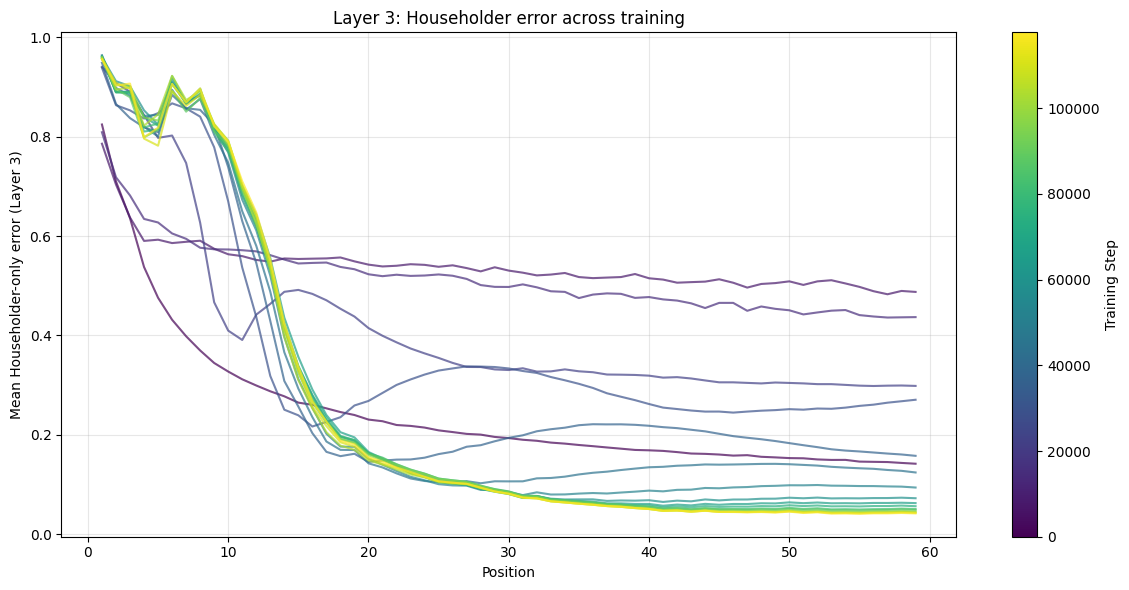

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.cm.viridis
iter_nums = [r[0] for r in all_training_results]
norm = plt.Normalize(vmin=min(iter_nums), vmax=max(iter_nums))

for iter_num, results in all_training_results:
    positions = sorted(set(r['pos'] for r in results[3]))
    pos_means = [np.mean([r['error'] for r in results[3] if r['pos'] == p]) for p in positions]
    ax.plot(positions, pos_means, color=cmap(norm(iter_num)), alpha=0.7)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Training Step')

ax.set_xlabel('Position')
ax.set_ylabel('Mean Householder-only error (Layer 3)')
ax.grid(True, alpha=0.3)
ax.set_title('Layer 3: Householder error across training')
plt.tight_layout()
plt.show()

## Analysis of Plot

This shows the Householder prediction error at layer 3 as a function of token idx (X-axis). The plot is colored by checkpoint number, with darker colors representing earlier checkpoints and lighter colors representing later checkpoints. You can clearly see the ability to use the householder mechanism to perform rotations emerging as training progresses. At random initialization (step 0) the householder error at layer 3 is 0.5-0.7 uniformly; after training the error drops to 0.03-0.07 for later token indices and *increases* to above 0.9 for the first 10 tokens. See the paragraphs below for an explanation of why we think this is.

Also notice that the "setup phase" (positions 0-15, where the error is high) is consistent across all checkpoints *after* the model learns to use the Householder product to compose rotations. This is architectural -- not a bug and not something learned. The model always needs additive writes in the first token indices to populate the state. What training does is teach layer 3 to rely on the Householder product once the state is populated $^*$ 


$^*$ I suppose some bag-of-heurstics fuzzy-lookup mechanism similar to the one proposed to be responsible for Claude's arithmetic capabilities (https://transformer-circuits.pub/2025/attribution-graphs/biology.html#dives-addition) could be responsible for predicting earlier sequences. but I actually doubt it. I might buy that as the mechanism for determining which permutation the model should perform -- again, this is not the mechanism responsible for that, only hte mechanism responsbile for executing the permutation -- but I think populating an initially empty state matrix is a better explanation for the difference in Householder errors between the first dozen tokens and the remaining tokens after that.


# DeltaProduct Conclusion

We have shown that the specific mechanism involved in updating state tracking in DeltaProduct is the householder product being performed in the final layer. It is responsible for predicting nearly all of the state update after the first 20 token indices (relative error below 0.05), while earlier positions are dominated by additive writes that populate the initially empty state matrix. 

In the final layer we use the householder products to perform a rotation on the hidden state which produces the updated state representation. We demonstrated that this mechanism is independent of the mechanism for determining which permutation to apply by showing that the householder error is the same whether the model's final prediction is correct or incorrect. When the model gets the wrong answer, the rotation mechanism executed faithfully, but was given the wrong rotation by upstream layers. We've also shown this mechanism emerges progressively during training and differs substantially from the signature shown by a randomly initialized set of model weights, where the Householder error is lower for earlier token indices (0.5-0.7 as opposed to >0.9 in the trained model) and much higher for later indices (0.4 - 0.6 vs. <0.05).



## Future Areas of Work 

- A strong piece of evidence that our hypothesis is right would be the presence of context-independent subspaces in the Householder product that activate consistently in response to a specific permutation or family of permutations. I attempted to look for these in a very crude way -- flattening the Householder products of each layer and taking the cosine similarity of in group (indices where the same action $a_t$ was applied) and out group (indices where an action other than $a_t$ was applied). Obviously this didn't work. More promising approaches would include: analyzing each head independently rather than flattening across heads, comparing the 2D rotation planes (doing SVD on $H_t - I$, for example) rather than the raw matrices, or comparing what the matrices do to a fixed set of probe vectors rather than comparing the matrices themselves.
- We did not analyze what the additive component in DeltaProduct is doing. Likely its mechanism is very similar to the one we uncover in our analysis of DeltaNet (see below), so we decided to skip it due to time and compute constratints. But proving or disproving that statement conclusively would be a useful thing to do to round out this study.

# Mechanistic Analysis of DeltaNet: KV Associative Memory or Rotations as Embedding Mechanism for Permutations?

Because DeltaNet has only a single Householder reflection per layer, it can't directly compose reflections into a rotation within a single recurrence step the way DeltaProduct does. Cross-layer composition is technically possible but seems like an implausible mechanism for gradient descent to learn; and it's outright *impossible* for it to learn to do cross layer composition into a delta product because beta values are clamped at 1. Therefore even if layers were composed, the result would be

$$(I - \beta_2 k_2 k_2^T)(I - \beta_1 k_1 k_1^T), \quad \beta_1, \beta_2 \in (0, 1)$$

For this to be a true Householder product (i.e. a composition of reflections yielding a rotation), we would need $\beta = 2$ so that each factor is a norm-preserving reflection $I - 2kk^T$. With $\beta \in (0,1)$, each factor is a contraction along its respective $k$ direction, and the composition of two contractions is another contraction, not a rotation.

So this isn't doing what we observed in DeltaProduct. What is it doing, then? We propose that DeltaNet tracks state through incremental rank-1 erase-and-write operations on its recurrent state matrix. At each timestep, the multiplicative term $\alpha(I - \beta k k^T)$ erases the component of $S_{t-1}$ along the $k$ direction, and the additive term $\beta v k^T$ writes new information back into that direction. With $\beta \approx 1$, the erasure is complete and the model fully clears one direction of the state and writes the updated vector to it. Over many timesteps and across 8 heads, the model reshapes its state representation one direction at a time, rather than rotating the entire state in a single operation as DeltaProduct does.

We think this is a particualrly useful hypothesis because it neatly explains why deltanet takes so much longer to train despite having the same capacity (this is a much less efficient way of tracking permutations than rotation via Householder Products)

For this to be true we should see 
- clear erase behavior ($\beta \approx 1$), especially in layer 3 which is where the model is likely doing most of the state tracking.
- cross-layer composition of Householder reflections providing no improvement over single-layer reflections, since the model is not using reflections for state tracking at all

### Step 0: Loading in Trained Model Weights and Dataset

In [2]:
# define model (already done, don't rewrite)
task = PermutationTask(num_items=NUM_ITEMS)
    
# Extract tokens and compute parity
state_tokens = {state.permutation: state.to_string() for state in task.states}
action_tokens = {action.permutation: action.to_string() for action in task.actions}
tokenizer = create_permutation_tokenizer(state_tokens, action_tokens)
config = GatedDeltaNetConfig(
    vocab_size=len(tokenizer),
    hidden_size=256,
    num_hidden_layers=4,
    num_heads=8,
    )
model = AutoModelForCausalLM.from_config(config)
state_dict = load_file(os.path.join(MODEL_DIR, CHECKPOINT_DIR, "model.safetensors"))
model.load_state_dict(state_dict)

print(model)
print(f"vocab size is: {len(tokenizer)}")
# read in test dataset
dataset = ChunkedDataset(DATA_DIR, max_len=MAX_LEN)

# for each example in test
    # run forward pass and store predicted probs and ground truth correct
    # slice test so it's only 12 permutations long (after this performance degrades bc I didn't train for very long)
    # for each permutation
        # for each layer
            # patch in incorrect label instead. 
            # complete corrupted forward pass
            # compute logit difference betweeen corrupted forward pass and ground truth forward pass
            # store this difference
# average them all together and put them in a big graph

SEQ_LEN = 12 # performance starts to drop off after 12 length tokens because I wasn't able to train for very long
NUM_EXAMPLES = 200 # number of sequences to run on
NUM_LAYERS = 4 # number of different layers we're ablating across
CORRUPT_POS = 3 # just picking a permutation to corrupt at frist. will vary and see if it makes a difference.
LAYER_NAMES = [f"model.layers.{i}" for i in range(NUM_LAYERS)]
all_actions = list(action_tokens.values())
model = model.to(device)
model.eval()



/data/snatha11/tilde-takehome/.venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/data/snatha11/tilde-takehome/.venv/lib/python3.11/site-packages/fla/modules/convolution.py:593: UserWarning: The `backend` parameter is set to `cuda`, but `causal_conv1d_fn` is not available. Switching to the Triton implementation instead. Consider installing `causal_conv1d` to enable the CUDA backend.
  warnings.warn(


GatedDeltaNetForCausalLM(
  (model): GatedDeltaNetModel(
    (embeddings): Embedding(241, 256)
    (layers): ModuleList(
      (0-3): 4 x GatedDeltaNetBlock(
        (attn_norm): RMSNorm(256, eps=1e-06)
        (attn): GatedDeltaNet(
          (q_proj): Linear(in_features=256, out_features=2048, bias=False)
          (k_proj): Linear(in_features=256, out_features=2048, bias=False)
          (v_proj): Linear(in_features=256, out_features=4096, bias=False)
          (a_proj): Linear(in_features=256, out_features=8, bias=False)
          (b_proj): Linear(in_features=256, out_features=8, bias=False)
          (q_conv1d): ShortConvolution(2048, 2048, kernel_size=(4,), stride=(1,), padding=(3,), groups=2048, bias=False, activation=silu, backend=triton)
          (k_conv1d): ShortConvolution(2048, 2048, kernel_size=(4,), stride=(1,), padding=(3,), groups=2048, bias=False, activation=silu, backend=triton)
          (v_conv1d): ShortConvolution(4096, 4096, kernel_size=(4,), stride=(1,), padding

GatedDeltaNetForCausalLM(
  (model): GatedDeltaNetModel(
    (embeddings): Embedding(241, 256)
    (layers): ModuleList(
      (0-3): 4 x GatedDeltaNetBlock(
        (attn_norm): RMSNorm(256, eps=1e-06)
        (attn): GatedDeltaNet(
          (q_proj): Linear(in_features=256, out_features=2048, bias=False)
          (k_proj): Linear(in_features=256, out_features=2048, bias=False)
          (v_proj): Linear(in_features=256, out_features=4096, bias=False)
          (a_proj): Linear(in_features=256, out_features=8, bias=False)
          (b_proj): Linear(in_features=256, out_features=8, bias=False)
          (q_conv1d): ShortConvolution(2048, 2048, kernel_size=(4,), stride=(1,), padding=(3,), groups=2048, bias=False, activation=silu, backend=triton)
          (k_conv1d): ShortConvolution(2048, 2048, kernel_size=(4,), stride=(1,), padding=(3,), groups=2048, bias=False, activation=silu, backend=triton)
          (v_conv1d): ShortConvolution(4096, 4096, kernel_size=(4,), stride=(1,), padding

### Step 1: Determining Where Information is Encoded

First we want to understand where the model encodes information about a new permutation $x_t$ when it encounters one. This might seem trivial — obviously it happens at position $t$ in the early layers, but it's worth verifying because it tells us which layers to focus on for the mechanistic analysis that follows, and whether the encoding is distributed across layers or concentrated in one.

**Experimental Setup:** We corrupt a single action token at position 2 by replacing it with a random different permutation, then run activation patching: for each (layer, position) pair, we patch the clean activation into the corrupted forward pass and measure how much of the logit difference is recovered. We do this across 200 examples for both length-9 and length-30 sequences.

We patch the residual stream in its entirety, as well as activations for the attention mechanism and the MLP in each layer specifically. 

100%|██████████| 200/200 [00:25<00:00,  7.94it/s]


Total accuracy across clean forward passes: 100.0%


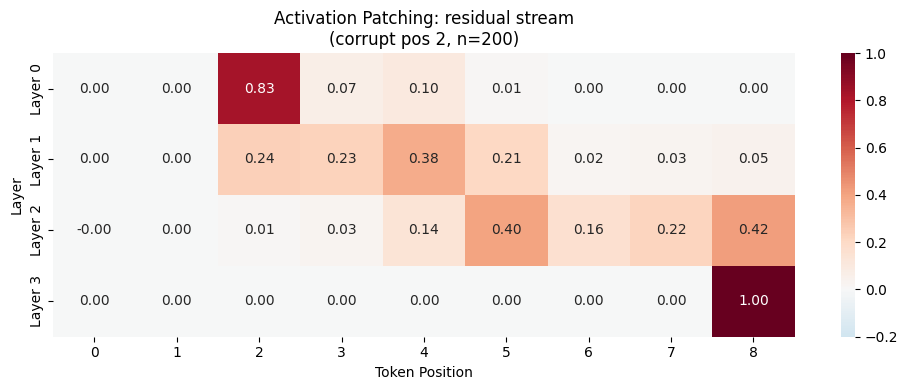

In [4]:
# trying a few different pairs to see if switching position we're corrupting changes things
results, n, _, _, _ = activation_patch(model, dataset, tokenizer, action_tokens,
                               seq_len=9, corrupt_pos=2, patch_site="model.layers.{layer_idx}")
plot_patch_results(results, seq_len=9, corrupt_pos=2, patch_site="residual stream", num_valid=n)

100%|██████████| 200/200 [00:23<00:00,  8.70it/s]


Total accuracy across clean forward passes: 93.8%


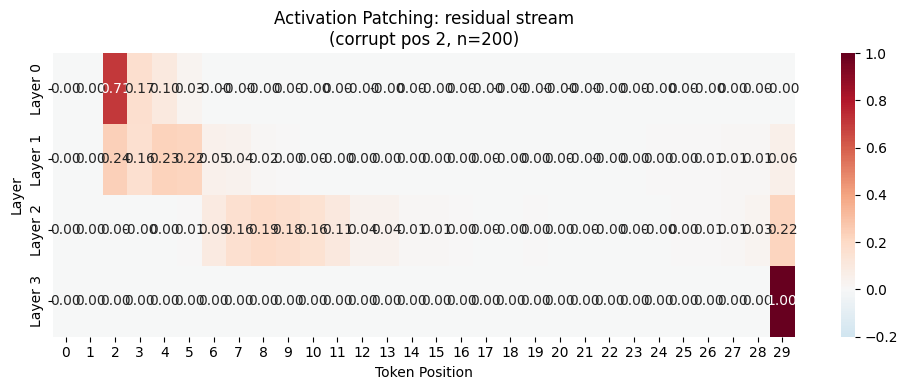

In [4]:
# trying a few different pairs to see if switching position we're corrupting changes things
results, n,_,_, _ = activation_patch(model, dataset, tokenizer, action_tokens,
                               seq_len=30, corrupt_pos=2, patch_site="model.layers.{layer_idx}")
plot_patch_results(results, seq_len=30, corrupt_pos=2, patch_site="residual stream", num_valid=n)

We can also patch the `attn` and `mlp` components specifically: 

100%|██████████| 200/200 [00:23<00:00,  8.41it/s]


Total accuracy across clean forward passes: 100.0%


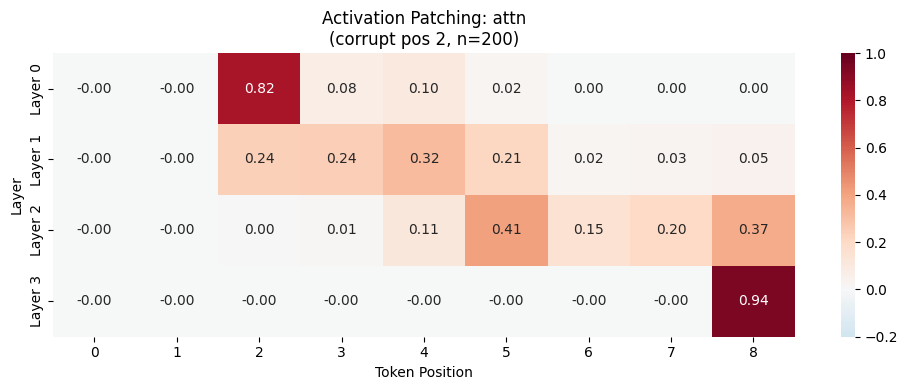

In [5]:
# Patch only the attention component
results_attn, n,_,_, _ = activation_patch(model, dataset, tokenizer, action_tokens,
    seq_len=9, corrupt_pos=2, patch_site="model.layers.{layer_idx}.attn")
plot_patch_results(results_attn, seq_len=9, corrupt_pos=2, patch_site="attn", num_valid=n)

100%|██████████| 200/200 [00:13<00:00, 15.07it/s]


Total accuracy across clean forward passes: 100.0%


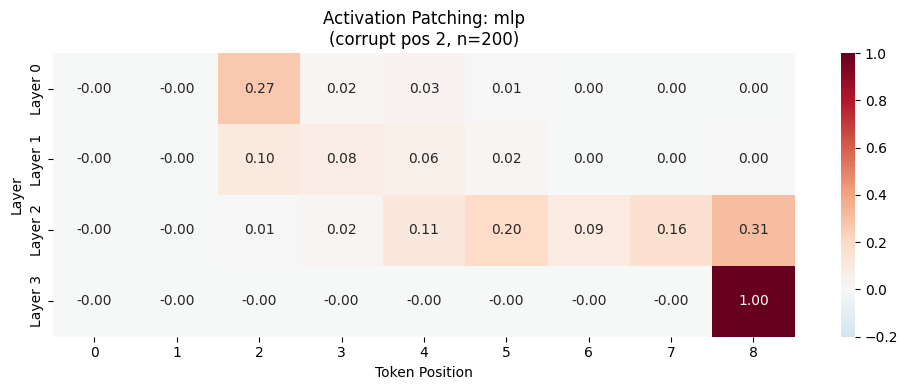

In [6]:
# Patch only the MLP component  
results_mlp, n, _, _, _ = activation_patch(model, dataset, tokenizer, action_tokens,
    seq_len=9, corrupt_pos=2, patch_site="model.layers.{layer_idx}.mlp")
plot_patch_results(results_mlp, seq_len=9, corrupt_pos=2, patch_site="mlp", num_valid=n)

# Analysis
These results look great! Layer 0 clearly captures most of the causal effect of the corrupted position. Patching just that one position in the residual stream results in recovering the correct answer 73% of the time. 
Layer 3 is a decoder that reads out the next token prediction from the state matrix $S_t$, so it makes sense that residual stream patching has no effect

The key takeaway from this is: Layer 0 produces an encoding of the permutation applied at timestep t, which acts upon the state primarily in later layers. How and where does it act upon the state? Let's find out


**Results:** Layer 0 at position 2 dominates: patching the residual stream there recovers 83% of the logit difference. Breaking this down by component, attention accounts for nearly all of it (0.82) while the MLP contributes much less (0.27). 

The MLP's contribution at layer 0 is likely an artifact of being downstream of attention in the residual stream. It processes the output of attention, so patching it partially recovers the attention signal. This pattern reverses at the final position in layer 3: the MLP contributes 1.00 while attention contributes 0.94. This makes sense beacuse layer 3's role is as a decoder, converting the internal state matrix to a next token prediction, which is something the MLP's nonlinearity would likely do well at. 

It's also worth noting how the causal effect of the corrupted token spreads across positions in layers 1 and 2 -- and how different this is from non-recurrent architectures. At layer 1, the effect is distributed across positions 2-5 (0.24, 0.24, 0.32, 0.21), which likely means the recurrent state is propagating the corrupted information forward through the sequence. By layer 2, the effect has shifted further toward later positions (0.41 at position 5, 0.37 at position 8). This is consistent with how RNNs carry corrupted information forward. In a transformer you'd expect to just see this effect concentrated at position 2, because every subsequent position can attend back to position 2. Not super relevant to hypothesis but still a cool little difference in information flow directly induced by the recurrence here.

We can also patch even more individaully at `k`, `q`, or `v`, but patching just one of those seems to destroy the causal relationship.

100%|██████████| 200/200 [00:11<00:00, 16.71it/s]


Total accuracy across clean forward passes: 100.0%


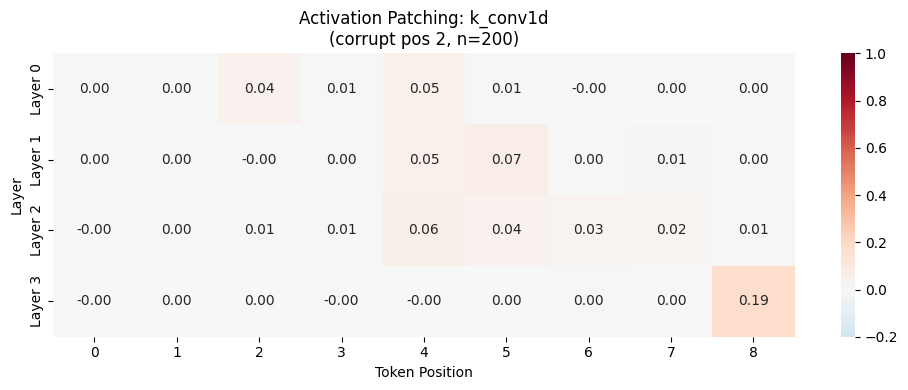

In [6]:
# Patch k_conv1d
results_k, n, _, _, _ = activation_patch(model, dataset, tokenizer, action_tokens,
    seq_len=9, corrupt_pos=2, patch_site="model.layers.{layer_idx}.attn.k_conv1d")
plot_patch_results(results_k, seq_len=9, corrupt_pos=2, patch_site="k_conv1d", num_valid=n)

100%|██████████| 200/200 [00:12<00:00, 16.61it/s]


Total accuracy across clean forward passes: 100.0%


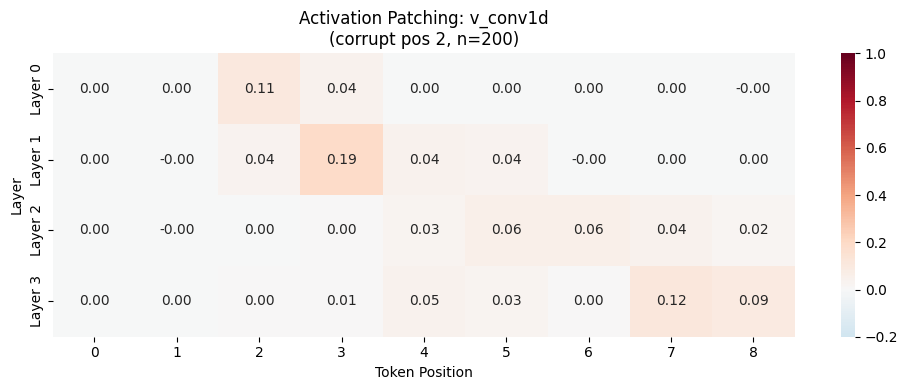

In [7]:
# Patch v_conv1d
results_v, n, _, _, _ = activation_patch(model, dataset, tokenizer, action_tokens,
    seq_len=9, corrupt_pos=2, patch_site="model.layers.{layer_idx}.attn.v_conv1d")
plot_patch_results(results_v, seq_len=9, corrupt_pos=2, patch_site="v_conv1d", num_valid=n)

100%|██████████| 200/200 [00:12<00:00, 16.65it/s]


Total accuracy across clean forward passes: 100.0%


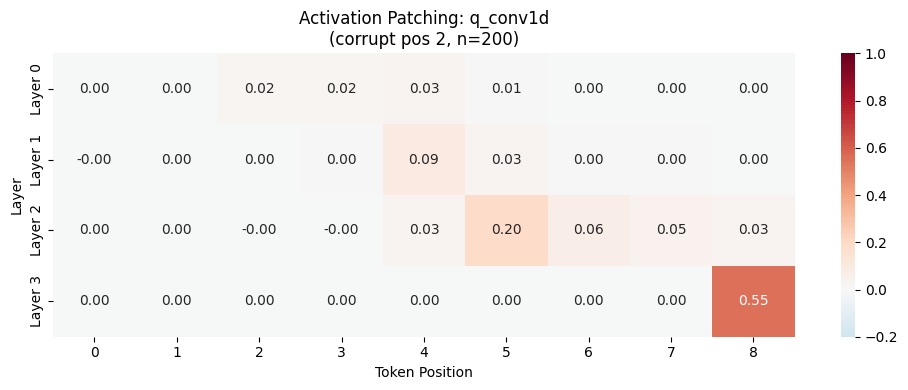

In [8]:
# Patch q_conv1d
results_q, n, _, _, _= activation_patch(model, dataset, tokenizer, action_tokens,
    seq_len=9, corrupt_pos=2, patch_site="model.layers.{layer_idx}.attn.q_conv1d")
plot_patch_results(results_q, seq_len=9, corrupt_pos=2, patch_site="q_conv1d", num_valid=n)

### Step 2: Decomposing Attention Output into Multiplicative and Additive Contributions

The DeltaNet recurrence updates its state as $S_t = mult \cdot S_{t-1} + add^\top$, where $mult$ is $\alpha(I - \beta k k^\top)$ and $add$ is $\beta v k^\top$ and the attention output at each position is $o_t = S_t \cdot q_t$. Substituting the recurrence into the output gives us an exact decomposition:

$$o_t = (mult \cdot S_{t-1}) \cdot q_t + add^\top \cdot q_t = o_{mult} + o_{add}$$

where $o_{mult}$ is the contribution from transforming the previous state (what the model would output if no new information were written) and $o_{add}$ is the contribution from the new rank-1 write (what the model would output if it ignored all previous state). 

for clarity 

$$ o_{mult} = \alpha(I - \beta k k^\top) \cdot S_{t-1} \cdot q_t $$
$$ o_{add} = \beta (k \cdot q_t) v $$


We compute $\|o_{mult}\| / \|o_{add}\|$ at each (layer, position) pair to see which mechanism dominates. We perform the same decomposition on the state matrix itself, comparing $\|mult \cdot S_{t-1}\|$ to $\|add^\top\|$.

starting sample 0
starting sample 10
starting sample 20
starting sample 30
starting sample 40
starting sample 50
starting sample 60
starting sample 70
starting sample 80
starting sample 90
starting sample 100
starting sample 110
starting sample 120
starting sample 130
starting sample 140
starting sample 150
starting sample 160
starting sample 170
starting sample 180
starting sample 190


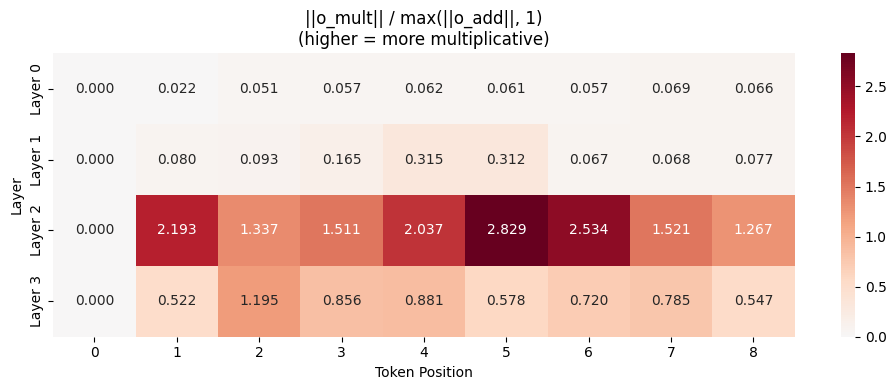

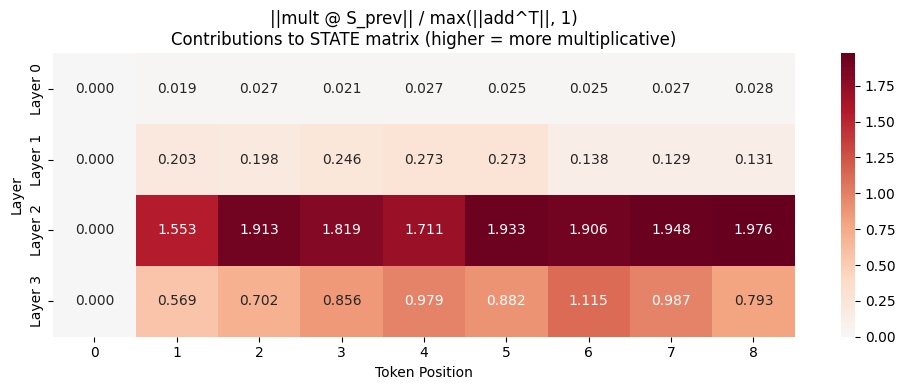

In [ ]:
import torch.nn.functional as F
import numpy as np

def compute_components(cache, layer, pos, model):
    """
    Extract the multiplicative and additive components of the GatedDeltaNet
    recurrence at a single timestep.
    
    The GatedDeltaNet maintains a state matrix S of shape (nh, dk, dv) per layer.
    At each timestep t, the recurrence updates S as:
    
        S_t = mult @ S_{t-1} + add^T
    
    where:
        mult = alpha * (I - beta * k @ k^T)    shape (nh, dk, dk)
        add  = beta * v @ k^T                   shape (nh, dv, dk)
    
    The multiplicative term (mult @ S_{t-1}) transforms the existing state.
    It is a gated combination of:
      - keeping the old state (the I term)
      - erasing information along the k direction (the k @ k^T term)
      - scaling by alpha which controls overall decay
    
    The additive term (add^T) writes new information into the state
    as a rank-1 outer product of v and k, scaled by beta.
    
    Args:
        cache: dictionary of hooked activations from a forward pass
        layer: which layer index (0 to num_layers-1)
        pos:   which token position in the sequence
        model: the model (needed for learned parameters A_log and dt_bias)
    
    Returns:
        multiplicative: (nh, dk, dk) matrix that left-multiplies S_{t-1}
        additive:       (nh, dv, dk) rank-1 update before transpose
    """
    
    # ---- Extract key vector k ----
    k = einops.rearrange(
        cache[f"model.layers.{layer}.attn.k_conv1d"][0, pos], 
        '(nh dk) -> nh dk', nh=8
    )
    k = F.normalize(k, p=2, dim=-1)
    
    # ---- Extract value vector v ----
    # Shape: (nh, dv) where dv=512 per head.
    # v is the "content" that gets written into the state matrix.
    v = einops.rearrange(
        cache[f"model.layers.{layer}.attn.v_conv1d"][0, pos], 
        '(nh dv) -> nh dv', nh=8
    )
    
    # ---- Extract beta (write gate) ----
    # Shape: (nh,) -- one scalar per head.
    # beta controls how strongly to write new info and erase old info
    beta = torch.sigmoid(cache[f"model.layers.{layer}.attn.b_proj"][0, pos])
    
    # ---- Compute alpha (decay gate) ----
    a_proj_out = cache[f"model.layers.{layer}.attn.a_proj"][0, pos]  # (nh,)
    attn = model.model.layers[layer].attn
    g = -attn.A_log.float().exp() * F.softplus(a_proj_out.float() + attn.dt_bias)
    alpha = g.exp()
    # print(f"alpha is {alpha.norm().item()}")
    
    # ---- Build the additive component ----
    # additive = beta * outer(v, k)
    # Shape: (nh, dv, dk)

    additive = einops.einsum(beta, v, k, 'nh, nh dv, nh dk -> nh dv dk')
    
    # ---- Build the multiplicative component ----
    # multiplicative = alpha * (I - beta * k @ k^T)
    # Shape: (nh, dk, dk)
    I = einops.repeat(torch.eye(256, device=k.device), 'i j -> nh i j', nh=8)
    k_outer_k = einops.einsum(beta, k, k, 'nh, nh i, nh j -> nh i j')
    multiplicative = einops.einsum(alpha, I - k_outer_k, 'nh, nh i j -> nh i j')
    
    return multiplicative, additive


# =========================================================================
# STEP 1: Collect ground truth recurrent states
# =========================================================================

# layer_idx = 3
seq_len = 9
ratio_map = np.zeros((4, seq_len))
state_ratio_map = np.zeros((4, seq_len))
num_samples = 200
for idx in range(num_samples):
    if idx % 10 == 0: 
        print(f"starting sample {idx}")
    for layer_idx in range(4):

        # idx=53 # 53rd sample in dataset. just picked random index for now
        tokens = dataset[idx]['story'].split()[:seq_len]
        input_ids = tokenizer(" ".join(tokens), return_tensors='pt').input_ids.cuda()
        seq_len = input_ids.shape[1]

        model.model.attn_mode = 'recurrent'
        actual_states = []
        past_kv = None

        with torch.no_grad():
            for t in range(seq_len):
                out = model(
                    input_ids=input_ids[:, t:t+1], 
                    past_key_values=past_kv, 
                    use_cache=True
                )
                past_kv = out.past_key_values
                # recurrent_state has shape (1, nh, dk, dv) = (1, 8, 256, 512)
                S_t = past_kv[layer_idx]['recurrent_state'].clone()
                actual_states.append(S_t)


        # =========================================================================
        # STEP 2: Collect intermediate projections via hooks
        # =========================================================================

        model.model.attn_mode = 'chunk'
        cache = {}

        hook_names = [
            f"model.layers.{layer_idx}.attn.k_conv1d",  # key after conv1d
            f"model.layers.{layer_idx}.attn.v_conv1d",  # value after conv1d
            f"model.layers.{layer_idx}.attn.b_proj",    # beta (write gate) projection
            f"model.layers.{layer_idx}.attn.a_proj",    # alpha (decay gate) projection
            f"model.layers.{layer_idx}.attn.q_proj",    # query projection
        ]

        handles = intervene(
            model, 
            layer_names=hook_names, 
            replacement_fn=store_activations(cache)
        )
        with torch.no_grad():
            model(input_ids=input_ids)
        for h in handles:
            h.remove()


        # =========================================================================
        # STEP 3: Reconstruct S_t manually and decompose the output
        # =========================================================================

        S_reconstructed = torch.zeros_like(actual_states[0])  # (1, 8, 256, 512)

        for t in range(seq_len):
            # Save the state BEFORE this update so we can use it
            # in the output decomposition
            S_prev = S_reconstructed.clone()

            # Get mult and add for this timestep
            mult, add = compute_components(cache, layer_idx, t, model)
            mult = mult.to(S_reconstructed.dtype)
            add = add.to(S_reconstructed.dtype)

            # ---- Reconstruct S_t ----

            S_reconstructed = einops.einsum(
                mult, S_reconstructed.squeeze(0),
                'nh i j, nh j dv -> nh i dv'
            ).unsqueeze(0) + add.permute(0, 2, 1).unsqueeze(0)

            # ---- Decompose the output ----
            # Get the query vector for this position
            # q shape: (nh, dk)
            q = einops.rearrange(
                cache[f"model.layers.{layer_idx}.attn.q_proj"][0, t],
                '(nh dk) -> nh dk', nh=8
            )

            o_mult = einops.einsum(
                mult, S_prev.squeeze(0), q,
                'nh i j, nh j dv, nh i -> nh dv'
            )

            o_add = einops.einsum(
                add.permute(0, 2, 1), q,
                'nh dk dv, nh dk -> nh dv'
            )
            # add values to heatmap
            ratio_map[layer_idx, t] += o_mult.norm().item() / max(o_add.norm().item(), 1.0)
            # ratio_map[layer_idx, t] = o_mult.norm().item() / max(o_add.norm().item(), 1.0)
            
            # add values to heatmap for state matrix
            state_mult_norm = einops.einsum(mult, S_prev.squeeze(0), 'nh i j, nh j dv -> nh i dv').norm().item()
            state_add_norm = add.permute(0, 2, 1).norm().item()
            state_ratio_map[layer_idx, t] += state_mult_norm / max(state_add_norm, 1.0)

            # ---- Verify reconstruction matches ground truth ----
            S_actual = actual_states[t]
            mae = (S_reconstructed - S_actual).mean().item()
            
            # keep track of buffers here for the mean norm (so this means add norm value to some mean buffer)
            
        # then down here print those mean norms

        # print(
        #     f"t={t}: "
        #     # f"o_mult.shape={o_mult.shape},"
        #     # f"o_add.shape={o_add.shape},"
        #     f"||o_mult||={o_mult.norm().item():.4f}, "
        #     f"||o_add||={o_add.norm().item():.4f}, "
        #     f"cosine={F.cosine_similarity(o_mult.flatten(), o_add.flatten(), dim=0).item():.4f},"
        #     f"t={t}: reconstruction MAE={mae:.2e}"
        # )
ratio_map /= num_samples
state_ratio_map /= num_samples

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    ratio_map,
    xticklabels=range(seq_len),
    yticklabels=[f"Layer {i}" for i in range(4)],
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".3f",
    ax=ax,
)
ax.set_xlabel("Token Position")
ax.set_ylabel("Layer")
ax.set_title("||o_mult|| / max(||o_add||, 1)\n(higher = more multiplicative)")
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    state_ratio_map,
    xticklabels=range(seq_len),
    yticklabels=[f"Layer {i}" for i in range(4)],
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".3f",
    ax=ax,
)
ax.set_xlabel("Token Position")
ax.set_ylabel("Layer")
ax.set_title("||mult @ S_prev|| / max(||add^T||, 1)\nContributions to STATE matrix (higher = more multiplicative)")
plt.tight_layout()
plt.show()

The top heatmap shows the ratio of the multiplicative to additive components in the **attention output** $o_t$ at each (layer, position pair). The bottom heatmap shows the same ratio but for the **state matrix** $S_t$. 

So this tells a very clear story: In our first analysis we determined via activation patching that the attention mechanism was causally responsible for encoding the new permutations for encoding the current action (permutation) at each position $t$. This analysis was intended to determine whether it was doing so via the additive component in some kind of kv associative memory write or via the multiplicative component.

The answer is that it varies layer-by-layer. In layers 0 and 1 the additive component completely dominates (layer 0 especially). This indicates
- The initial encoding of the most recent permutation $x_t$ is done by the *additive* component $\beta v k^T$ via an associative memory write to the model's state 

Meanwhile, in layers 2 and 3 the multiplicative component dominates (layer 2 especially -- layer 3 is more evenly balanced). This indicates layer 2 is not writing new information so much as manipulating the existing information written by layers 0 and 1 using using the $\alpha(I - \beta k k^\top)$ term to selectively erase and reshape the associations in the state. the additive component is quiet, allowing those manipulations to propagate forward. Then in layer 3 the multiplicative component is less dominant, but it's worth noting that the multiplicative components contributions to the *state matrix* are relatively higher than its contributions to the actual output. 

This is consistent with the role of the multiplicative component being state maintenance (preserving and selective erasing directions in the state matrix) rather than state readout (which is done by the query projectin and the additive writes that populate the directions the query reads from) -- that's my working theory, at least. But regardless, the layerwise progression indicated by these results (write, write, manipulate, manipulate & read) is consistent with the erase-and-write mechanism we proposed. The model builds up state representations through additive writes in early layers, reshapes them through selective erasure using the multiplicative component in layer 2, and reads out the prediction in layer 3.

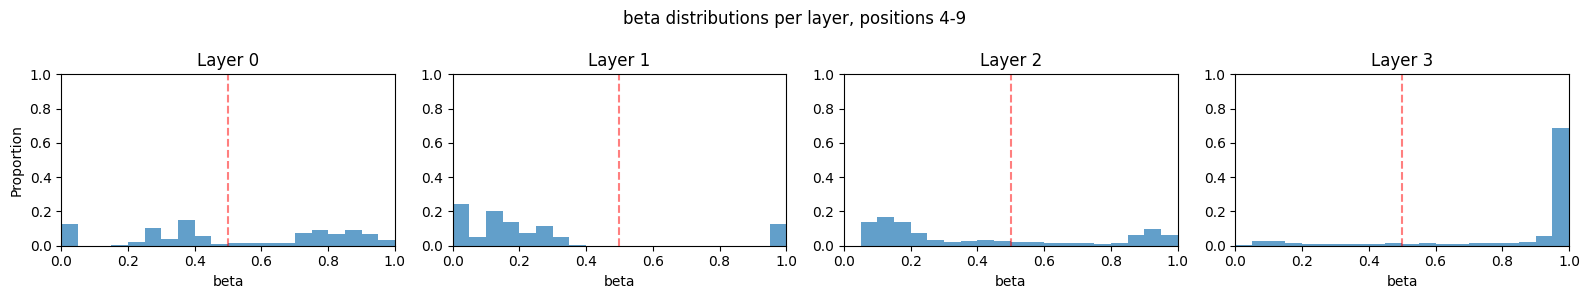

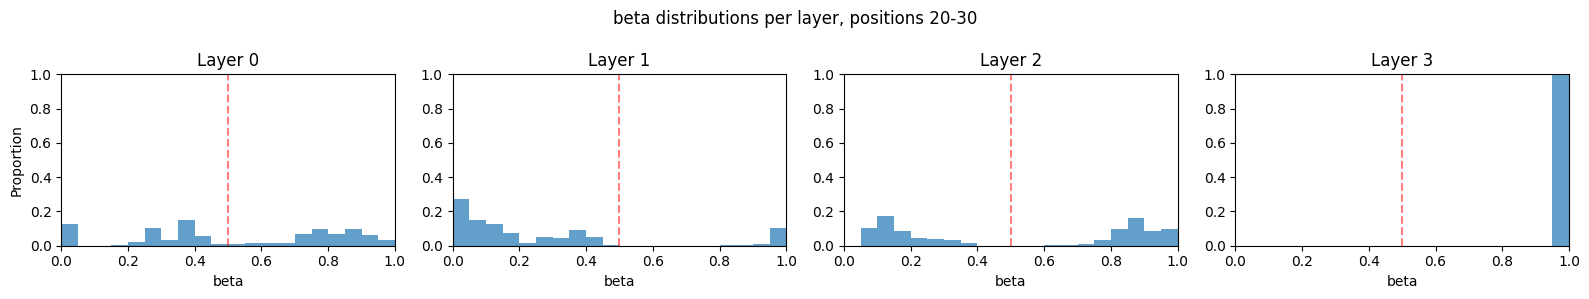

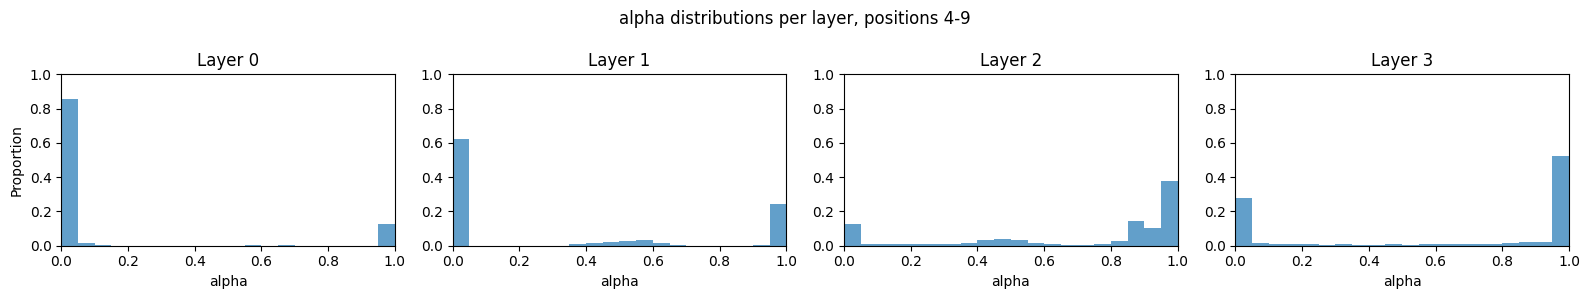

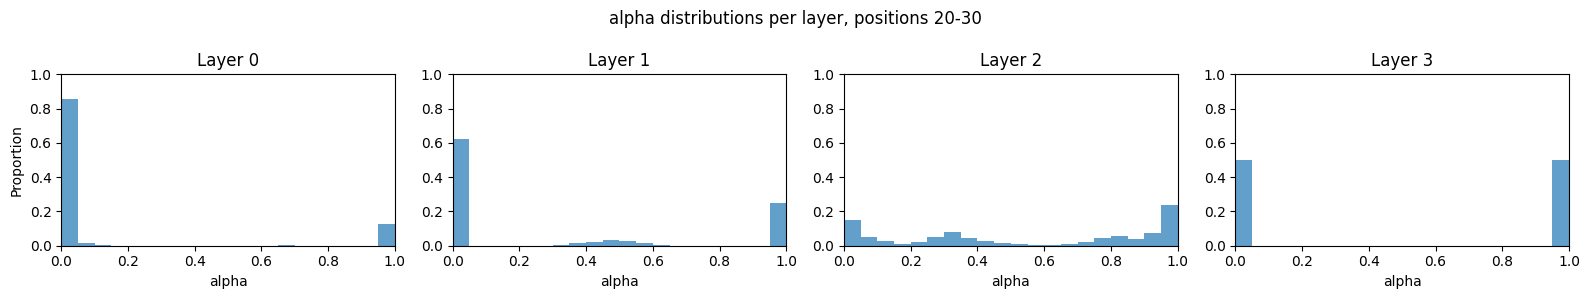

In [7]:
def collect_gate_values(model, dataset, tokenizer, num_samples=200, max_seq_len=30, pos_range=(20, 30)):
    """Collect beta and alpha values across samples for a given position range."""
    beta_values = defaultdict(list)
    alpha_values = defaultdict(list)
    
    for idx in range(num_samples):
        tokens = dataset[idx]['story'].split()[:max_seq_len]
        input_ids = tokenizer(" ".join(tokens), return_tensors='pt').input_ids.cuda()
        
        for layer_idx in range(4):
            cache = {}
            handles = intervene(model, layer_names=[
                f"model.layers.{layer_idx}.attn.b_proj",
                f"model.layers.{layer_idx}.attn.a_proj",
            ], replacement_fn=store_activations(cache))
            with torch.no_grad():
                model.model.attn_mode = 'chunk'
                model(input_ids=input_ids)
            for h in handles:
                h.remove()
            
            for t in range(pos_range[0], min(pos_range[1], input_ids.shape[1])):
                beta = torch.sigmoid(cache[f"model.layers.{layer_idx}.attn.b_proj"][0, t]).detach().cpu()
                beta_values[layer_idx].extend(beta.tolist())
                
                attn = model.model.layers[layer_idx].attn
                a_proj_out = cache[f"model.layers.{layer_idx}.attn.a_proj"][0, t]
                alpha = (-attn.A_log.float().exp() * F.softplus(a_proj_out.float() + attn.dt_bias)).exp()
                alpha_values[layer_idx].extend(alpha.detach().cpu().tolist())
    
    return beta_values, alpha_values

def plot_gate_distribution(values, gate_name, pos_range):
    fig, axes = plt.subplots(1, 4, figsize=(16, 3))
    for layer_idx in range(4):
        v = values[layer_idx]
        counts, bin_edges = np.histogram(v, bins=20, range=(0, 1))
        proportions = counts / counts.sum()
        axes[layer_idx].bar(bin_edges[:-1], proportions, width=np.diff(bin_edges), align='edge', alpha=0.7)
        axes[layer_idx].set_title(f"Layer {layer_idx}")
        axes[layer_idx].set_xlabel(gate_name)
        axes[layer_idx].set_ylim(0, 1)
        axes[layer_idx].set_xlim(0, 1)
        if gate_name == "beta":
            axes[layer_idx].axvline(x=0.5, color='r', linestyle='--', alpha=0.5)
    axes[0].set_ylabel("Proportion")
    fig.suptitle(f"{gate_name} distributions per layer, positions {pos_range[0]}-{pos_range[1]}")
    plt.tight_layout()
    plt.show()


# Early positions (4-9)
beta_early, alpha_early = collect_gate_values(model, dataset, tokenizer, pos_range=(4, 9), max_seq_len=9)

# Later positions (20-30)
beta_late, alpha_late = collect_gate_values(model, dataset, tokenizer, pos_range=(20, 30), max_seq_len=30)

# plotting
plot_gate_distribution(beta_early, "beta", (4, 9))
plot_gate_distribution(beta_late, "beta", (20, 30))
plot_gate_distribution(alpha_early, "alpha", (4, 9))
plot_gate_distribution(alpha_late, "alpha", (20, 30))

## Analysis of Plot:

We plot the distributions of beta (write gate) and alpha (decay gate) at each layer for two position ranges: positions 4-9 (early tokens where the model is still populating the state matrix but accuracy is high) and positions 20-30 (later tokens where, based on our DeltaProduct analysis, we expect the state to be well-established). We separate these ranges because the model may use different strategies at different points in the sequence.

Important takeaways 
1. $\beta$ values are capped at 1.0 so this is *not* doing a rotation. Obviously this is an architectural design choice but it's worth reiterating.
2. The most striking observation is the collapse of *all* beta values to 1 AND all alpha values to 0 or 1 at layer 3 for positions 20-30. This corresponds to a complete erasure of information along the $k$ direction in each head's 256-dimensional state space, followed by a write of new information $vk^\top$ into that same direction. This is exactly the erase-and-write pattern our hypothesis predicts.
3. All alpha values at layer 3 are either near 0 (complete decay of the head's state) or near 1 (preservation of everything except the erased $k$ direction). We wonder if the model is learning to use some heads as "short term" memory that gets written to and swiftly erased, and others as long term memory. But it's possible this is an artifact of incomplete training.


Connecting back to our hypothesis: if DeltaNet were using its multiplicative component for rotations (even imperfect ones), we would expect beta values distributed around intermediate values and alpha consistently near 1 (to preserve state while transforming it). Instead we see beta clamped to 1 and alpha bimodal, which seems to be the signature of the model agressively erasing and rewriting, not gradually rotating or transforming, its state space. So that seems to lend substantial evidence to our hypothesis that DeltaNet learns to do state tracking by writing and erasing its state space according to new permutations




## Conclusions

We found the following pieces of evidence:

1. **Activation patching** shows that layer 0's attention mechanism is causally responsible for encoding the current permutation, with the effect propagating forward through the recurrent state across subsequent positions (which again is a signature pattern for recurrent architectures that woudln't appear in a feed forward transformer)

2. **Division of Labor Across Layers** additive component of attention dominates the output in layers 0-1 (writing action representations into state), while layer 2 is dominated by the multiplicative component (manipulating existing state). Layer 3 is mixed (readout with state maintenance).

3. **alpha and beta distributions** collapse to bimodal (0 or 1) and respectively as token index increases. This is a signature of a model maintaning its state via iterative erases and writes. 


Taken together, these results support our hypothesis that DeltaNet tracks state through incremental rank-1 erase-and-write operations rather than rotations. Each head erases one direction of its 256-dimensional state and writes new information into that direction at each step. This is a fundamentally less efficient mechanism for implementing permutations than DeltaProduct's Householder rotations because the model must reshape its state one direction at a time rather than rotating the entire representation in a single operation. We believe this difference in mechanism is the primary explanation for DeltaNet's slower convergence and lower accuracy compared to DeltaProduct under equivalent training compute.